# Publication Date Trends Analysis

This notebook analyzes trends in extracted fields (like Parameters) over time using publication dates.
We can visualize how model characteristics have evolved by looking at extraction runs within specific ID ranges.

In [1]:
# Import required libraries
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import re

# Set up matplotlib style
plt.style.use('default')
sns.set_palette("husl")

# Add the project root to the path so we can import database modules
sys.path.append(os.path.dirname(os.path.abspath('')))

# Import database modules
from db.db_utils import get_connection
from db.paper_dao import PaperDAO
from db.extraction_dao import ExtractionDAO

print(" Libraries imported successfully!")

 Libraries imported successfully!


In [2]:
def visualize_field_trends(field_name, run_id_start=None, run_id_end=None, 
                          figsize=(12, 8), show_numeric_trend=True, na_values=None, log_scale=False):
    """
    Visualize trends in extracted fields over time using publication dates.
    
    Args:
        field_name (str): Name of the field to analyze (e.g., 'Parameters', 'Architecture')
        run_id_start (int, optional): Starting extraction run ID (inclusive)
        run_id_end (int, optional): Ending extraction run ID (inclusive)
        figsize (tuple): Figure size for the plot
        show_numeric_trend (bool): Whether to show trend line for numeric values
        na_values (list, optional): Custom list of values to treat as N/A. 
                                   Default: ['n/a', '', 'N/A', 'unknown', 'None', 'null']
        log_scale (bool): Whether to use logarithmic scale for y-axis (useful for parameter counts)
    
    Returns:
        pandas.DataFrame: The data used for plotting
    """
    
    # Default N/A values if not specified
    if na_values is None:
        na_values = ['n/a', '', 'N/A', 'unknown', 'None', 'null', 'not specified', 
                     'not available', 'not reported', 'unclear', '-']
    
    # Build the query to get extraction data with publication dates
    conn = get_connection()
    
    # Base query with correct table names
    query = """
    SELECT 
        ef.value,
        ef.confidence,
        ef.run_id,
        p.published_date,
        p.arxiv_id,
        p.title,
        m.name as model_name,
        m.provider as model_provider,
        er.run_date
    FROM extracted_fields ef
    JOIN extraction_runs er ON ef.run_id = er.id
    JOIN papers p ON er.paper_id = p.id
    JOIN models m ON er.model_id = m.id
    WHERE ef.field_name = %s
    AND p.published_date IS NOT NULL
    """
    
    params = [field_name]
    
    # Add run ID filters if specified
    if run_id_start is not None:
        query += " AND ef.run_id >= %s"
        params.append(run_id_start)
    
    if run_id_end is not None:
        query += " AND ef.run_id <= %s"
        params.append(run_id_end)
    
    query += " ORDER BY p.published_date"
    
    # Execute query
    cursor = conn.cursor()
    cursor.execute(query, params)
    results = cursor.fetchall()
    conn.close()
    
    if not results:
        print(f"No data found for field '{field_name}' in the specified run ID range.")
        return None
    
    # Convert to DataFrame
    df = pd.DataFrame(results, columns=[
        'value', 'confidence', 'run_id', 'published_date', 'arxiv_id', 
        'title', 'model_name', 'model_provider', 'run_date'
    ])
    
    print(f"Found {len(df)} data points for field '{field_name}'")
    print(f"Date range: {df['published_date'].min()} to {df['published_date'].max()}")
    print(f"Run ID range: {df['run_id'].min()} to {df['run_id'].max()}")
    print(f"N/A values being treated as: {na_values}")
    if log_scale:
        print(" Using logarithmic scale for y-axis")
    
    # Create the plot
    fig, axes = plt.subplots(2, 1, figsize=figsize, height_ratios=[3, 1])
    
    # Main scatter plot
    ax1 = axes[0]
    
    # Try to extract numeric values for trend analysis
    numeric_values = []
    categories = []
    na_count = 0
    
    for idx, value in enumerate(df['value']):
        # Check if value is N/A using custom na_values list
        if pd.isna(value) or str(value).strip().lower() in [str(na).strip().lower() for na in na_values]:
            numeric_values.append(np.nan)
            categories.append('N/A')
            na_count += 1
            continue
            
        # Try to extract numbers (like parameter counts)
        numbers = re.findall(r'[\d,]+\.?\d*', str(value))
        if numbers:
            # Take the largest number found (often the parameter count)
            try:
                num_str = numbers[-1].replace(',', '')
                numeric_val = float(num_str)
                
                # For log scale, keep original values; for linear scale, convert to millions
                if log_scale:
                    # Keep original scale for log visualization
                    numeric_values.append(numeric_val)
                else:
                    # Convert to millions if it's a large number (for linear scale)
                    if numeric_val > 1000:
                        numeric_val = numeric_val / 1_000_000  # Convert to millions
                    numeric_values.append(numeric_val)
                categories.append('Numeric')
            except:
                numeric_values.append(np.nan)
                categories.append(str(value)[:20])  # Truncate long strings
        else:
            numeric_values.append(np.nan)
            categories.append(str(value)[:20])  # Truncate long strings
    
    df['numeric_value'] = numeric_values
    df['category'] = categories
    
    print(f"N/A values found: {na_count} ({na_count/len(df)*100:.1f}%)")
    
    # Color by model provider
    providers = df['model_provider'].unique()
    colors = plt.cm.Set1(np.linspace(0, 1, len(providers)))
    provider_colors = dict(zip(providers, colors))
    
    # Plot numeric values
    numeric_mask = ~pd.isna(df['numeric_value'])
    na_mask = df['category'] == 'N/A'
    
    if numeric_mask.sum() > 0:
        for provider in providers:
            mask = (df['model_provider'] == provider) & numeric_mask
            if mask.sum() > 0:
                ax1.scatter(df[mask]['published_date'], df[mask]['numeric_value'], 
                           c=[provider_colors[provider]], label=f'{provider} (numeric)',
                           alpha=0.7, s=60)
        
        # Add trend line if requested and we have enough numeric data
        if show_numeric_trend and numeric_mask.sum() > 2:
            numeric_df = df[numeric_mask].copy()
            # Convert dates to numeric for regression (use timestamp conversion)
            try:
                # Convert timezone-aware datetime to timestamp (seconds since epoch)
                df['published_date'] = pd.to_datetime(df['published_date'], utc=True)
                numeric_df['date_numeric'] = numeric_df['published_date'].astype('int64') // 10**9
                
                # For log scale, use log values for regression
                if log_scale:
                    # Filter out zero and negative values for log scale
                    positive_mask = numeric_df['numeric_value'] > 0
                    if positive_mask.sum() > 2:
                        log_numeric_df = numeric_df[positive_mask].copy()
                        log_values = np.log10(log_numeric_df['numeric_value'])
                        
                        # Simple linear regression on log values
                        z = np.polyfit(log_numeric_df['date_numeric'], log_values, 1)
                        p = np.poly1d(z)
                        
                        # Convert back to original scale for plotting
                        trend_log_values = p(log_numeric_df['date_numeric'])
                        trend_values = 10 ** trend_log_values
                        
                        ax1.plot(log_numeric_df['published_date'], trend_values, 
                               "r--", alpha=0.8, linewidth=2, label='Trend (log scale)')
                else:
                    # Simple linear regression
                    z = np.polyfit(numeric_df['date_numeric'], numeric_df['numeric_value'], 1)
                    p = np.poly1d(z)
                    ax1.plot(numeric_df['published_date'], p(numeric_df['date_numeric']), 
                            "r--", alpha=0.8, linewidth=2, label='Trend (numeric)')
            except Exception as e:
                print(f"️  Could not compute trend line: {e}")
    
    # Set log scale if requested
    if log_scale and numeric_mask.sum() > 0:
        # Filter out zero and negative values for log scale
        positive_values = df[numeric_mask]['numeric_value']
        if (positive_values > 0).sum() > 0:
            ax1.set_yscale('log')
            ax1.set_ylabel(f'{field_name} (log scale)')
        else:
            print("️  Cannot use log scale: no positive values found")
            ax1.set_ylabel(f'{field_name}')
    else:
        ax1.set_ylabel(f'{field_name} (Millions if numeric)')
    
    # Plot N/A values at the bottom for visibility (only if not using log scale)
    if na_mask.sum() > 0 and not log_scale:
        y_na = -0.1 * (ax1.get_ylim()[1] - ax1.get_ylim()[0]) if numeric_mask.sum() > 0 else 0
        for provider in providers:
            mask = (df['model_provider'] == provider) & na_mask
            if mask.sum() > 0:
                ax1.scatter(df[mask]['published_date'], [y_na] * mask.sum(), 
                           c=[provider_colors[provider]], label=f'{provider} (N/A)',
                           alpha=0.5, s=30, marker='x')
    elif na_mask.sum() > 0 and log_scale:
        # For log scale, show N/A values at a very small positive value
        min_positive = df[numeric_mask & (df['numeric_value'] > 0)]['numeric_value'].min() if (df[numeric_mask]['numeric_value'] > 0).sum() > 0 else 1
        y_na = min_positive / 10
        for provider in providers:
            mask = (df['model_provider'] == provider) & na_mask
            if mask.sum() > 0:
                ax1.scatter(df[mask]['published_date'], [y_na] * mask.sum(), 
                           c=[provider_colors[provider]], label=f'{provider} (N/A)',
                           alpha=0.5, s=30, marker='x')
    
    ax1.set_xlabel('Publication Date')
    scale_info = " (log scale)" if log_scale else ""
    ax1.set_title(f'Trend Analysis: "{field_name}" Over Time{scale_info}')
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.grid(True, alpha=0.3)
    
    # Rotate x-axis labels for better readability
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
    
    # Bottom plot: Confidence distribution over time
    ax2 = axes[1]
    # Color confidence points by whether they're N/A or not
    confidence_colors = ['red' if na else 'gray' for na in na_mask]
    ax2.scatter(df['published_date'], df['confidence'], alpha=0.6, c=confidence_colors, s=30)
    ax2.set_xlabel('Publication Date')
    ax2.set_ylabel('Confidence')
    ax2.set_title('Extraction Confidence Over Time (Red = N/A values)')
    ax2.grid(True, alpha=0.3)
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Print some statistics
    print(f"\n Statistics for '{field_name}':")
    print(f"  • Total extractions: {len(df)}")
    print(f"  • Numeric values found: {numeric_mask.sum()}")
    print(f"  • N/A values: {na_count} ({na_count/len(df)*100:.1f}%)")
    print(f"  • Average confidence: {df['confidence'].mean():.1f}")
    print(f"  • Average confidence (excluding N/A): {df[~na_mask]['confidence'].mean():.1f}")
    print(f"  • Unique models: {df['model_name'].nunique()}")
    print(f"  • Model providers: {', '.join(df['model_provider'].unique())}")
    
    if numeric_mask.sum() > 0:
        if log_scale:
            print(f"  • Value range: {df[numeric_mask]['numeric_value'].min():.0f} - {df[numeric_mask]['numeric_value'].max():.0f}")
        else:
            print(f"  • Numeric range: {df[numeric_mask]['numeric_value'].min():.2f}M - {df[numeric_mask]['numeric_value'].max():.2f}M")
    
    # Show breakdown of N/A values
    if na_count > 0:
        print(f"\n N/A Value Breakdown:")
        na_breakdown = df[na_mask]['value'].value_counts()
        for value, count in na_breakdown.head(10).items():
            print(f"  • '{value}': {count} times")
    
    return df

# Example usage function with custom N/A values and log scale support
def analyze_common_fields(run_id_start=None, run_id_end=None, custom_na_values=None, use_log_scale=False):
    """
    Analyze trends for commonly extracted fields.
    """
    common_fields = ['Parameters', 'Architecture', 'Dataset', 'Performance']
    
    for field in common_fields:
        print(f"\n{'='*60}")
        print(f"Analyzing: {field}")
        print('='*60)
        try:
            df = visualize_field_trends(field, run_id_start, run_id_end, 
                                      na_values=custom_na_values, log_scale=use_log_scale)
            if df is not None:
                print(f" Successfully analyzed {field}")
            else:
                print(f"️  No data found for {field}")
        except Exception as e:
            print(f" Error analyzing {field}: {e}")

print(" Trend analysis functions loaded (with custom N/A support and natural log scale)!")

 Trend analysis functions loaded (with custom N/A support and natural log scale)!


In [3]:
def explore_available_fields():
    """
    Explore what fields are available in the database and their frequency.
    """
    conn = get_connection()
    cursor = conn.cursor()
    
    query = """
    SELECT ef.field_name, COUNT(*) as count,
           MIN(ef.run_id) as min_run_id,
           MAX(ef.run_id) as max_run_id
    FROM extracted_fields ef
    GROUP BY ef.field_name
    ORDER BY count DESC
    """
    
    cursor.execute(query)
    results = cursor.fetchall()
    conn.close()
    
    df = pd.DataFrame(results, columns=['field_name', 'count', 'min_run_id', 'max_run_id'])
    
    print(" Available Fields in Database:")
    print("=" * 60)
    for _, row in df.iterrows():
        print(f"  {row['field_name']:<20} | Count: {row['count']:<6} | Run IDs: {row['min_run_id']}-{row['max_run_id']}")
    
    return df

def get_run_id_ranges():
    """
    Get information about extraction run ID ranges.
    """
    conn = get_connection()
    cursor = conn.cursor()
    
    query = """
    SELECT 
        MIN(er.id) as min_run_id,
        MAX(er.id) as max_run_id,
        COUNT(*) as total_runs,
        COUNT(DISTINCT p.id) as unique_papers,
        MIN(p.published_date) as earliest_paper,
        MAX(p.published_date) as latest_paper
    FROM extraction_runs er
    JOIN papers p ON er.paper_id = p.id
    WHERE p.published_date IS NOT NULL
    """
    
    cursor.execute(query)
    result = cursor.fetchone()
    conn.close()
    
    print(" Extraction Run Information:")
    print("=" * 40)
    print(f"  Run ID range: {result[0]} - {result[1]}")
    print(f"  Total runs: {result[2]}")
    print(f"  Unique papers: {result[3]}")
    print(f"  Paper date range: {result[4]} to {result[5]}")
    
    return {
        'min_run_id': result[0],
        'max_run_id': result[1],
        'total_runs': result[2],
        'unique_papers': result[3],
        'earliest_paper': result[4],
        'latest_paper': result[5]
    }

def visualize_field_trends(field_name, run_id_start=None, run_id_end=None, 
                          figsize=(12, 10), show_numeric_trend=True, na_values=None, log_scale=False):
    """
    Visualize trends in extracted field values over time, with optional log scale.
    
    Parameters:
        field_name (str): Name of the field to analyze (e.g., 'Parameters')
        run_id_start (int, optional): Starting extraction run ID (inclusive)
        run_id_end (int, optional): Ending extraction run ID (inclusive)
        figsize (tuple): Figure size for the plot
        show_numeric_trend (bool): Whether to show trend line for numeric values
        na_values (list, optional): Custom list of values to treat as N/A. 
                                   Default: ['n/a', '', 'N/A', 'unknown', 'None', 'null']
        log_scale (bool): Whether to use logarithmic scale for y-axis (useful for parameter counts)
    
    Returns:
        pandas.DataFrame: The data used for plotting
    """
    
    # Default N/A values if not specified
    if na_values is None:
        na_values = ['n/a', '', 'N/A', 'unknown', 'None', 'null', 'not specified', 
                     'not available', 'not reported', 'unclear', '-']
    
    # Build the query to get extraction data with publication dates
    conn = get_connection()
    
    # Base query with correct table names
    query = """
    SELECT 
        ef.value,
        ef.confidence,
        ef.run_id,
        p.published_date,
        p.arxiv_id,
        p.title,
        m.name as model_name,
        m.provider as model_provider,
        er.run_date
    FROM extracted_fields ef
    JOIN extraction_runs er ON ef.run_id = er.id
    JOIN papers p ON er.paper_id = p.id
    JOIN models m ON er.model_id = m.id
    WHERE ef.field_name = %s
    AND p.published_date IS NOT NULL
    """
    
    params = [field_name]
    
    # Add run ID filters if specified
    if run_id_start is not None:
        query += " AND ef.run_id >= %s"
        params.append(run_id_start)
    
    if run_id_end is not None:
        query += " AND ef.run_id <= %s"
        params.append(run_id_end)
    
    query += " ORDER BY p.published_date"
    
    # Execute query
    cursor = conn.cursor()
    cursor.execute(query, params)
    results = cursor.fetchall()
    conn.close()
    
    if not results:
        print(f"No data found for field '{field_name}' in the specified run ID range.")
        return None
    
    # Convert to DataFrame
    df = pd.DataFrame(results, columns=[
        'value', 'confidence', 'run_id', 'published_date', 'arxiv_id', 
        'title', 'model_name', 'model_provider', 'run_date'
    ])
    
    print(f"Found {len(df)} data points for field '{field_name}'")
    print(f"Date range: {df['published_date'].min()} to {df['published_date'].max()}")
    print(f"Run ID range: {df['run_id'].min()} to {df['run_id'].max()}")
    print(f"N/A values being treated as: {na_values}")
    if log_scale:
        print(" Using logarithmic scale for y-axis")
    
    # Create the plot
    fig, axes = plt.subplots(2, 1, figsize=figsize, height_ratios=[3, 1])
    
    # Main scatter plot
    ax1 = axes[0]
    
    # Try to extract numeric values for trend analysis
    numeric_values = []
    categories = []
    na_count = 0
    
    for idx, value in enumerate(df['value']):
        # Check if value is N/A using custom na_values list
        if pd.isna(value) or str(value).strip().lower() in [str(na).strip().lower() for na in na_values]:
            numeric_values.append(np.nan)
            categories.append('N/A')
            na_count += 1
            continue
            
        # Try to extract numbers (like parameter counts)
        numbers = re.findall(r'[\d,]+\.?\d*', str(value))
        if numbers:
            # Take the largest number found (often the parameter count)
            try:
                num_str = numbers[-1].replace(',', '')
                numeric_val = float(num_str)
                
                # Always keep original values - scale conversion will be handled in axis labeling
                numeric_values.append(numeric_val)
                categories.append('Numeric')
            except:
                numeric_values.append(np.nan)
                categories.append(str(value)[:20])  # Truncate long strings
        else:
            numeric_values.append(np.nan)
            categories.append(str(value)[:20])  # Truncate long strings
    
    df['numeric_value'] = numeric_values
    df['category'] = categories
    
    print(f"N/A values found: {na_count} ({na_count/len(df)*100:.1f}%)")
    
    # Color by model provider
    providers = df['model_provider'].unique()
    colors = plt.cm.Set1(np.linspace(0, 1, len(providers)))
    provider_colors = dict(zip(providers, colors))
    
    # Plot numeric values
    numeric_mask = ~pd.isna(df['numeric_value'])
    na_mask = df['category'] == 'N/A'
    
    if numeric_mask.sum() > 0:
        for provider in providers:
            mask = (df['model_provider'] == provider) & numeric_mask
            if mask.sum() > 0:
                ax1.scatter(df[mask]['published_date'], df[mask]['numeric_value'], 
                           c=[provider_colors[provider]], label=f'{provider} (numeric)',
                           alpha=0.7, s=60)
        
        # Add trend line if requested and we have enough numeric data
        if show_numeric_trend and numeric_mask.sum() > 2:
            numeric_df = df[numeric_mask].copy()
            # Convert dates to numeric for regression (use timestamp conversion)
            try:
                # Ensure timezone-aware datetime conversion
                numeric_df['published_date'] = pd.to_datetime(numeric_df['published_date'], utc=True)
                numeric_df['date_numeric'] = numeric_df['published_date'].astype('int64') // 10**9
                
                # For log scale, use log values for regression
                if log_scale:
                    # Filter out zero and negative values for log scale
                    positive_mask = numeric_df['numeric_value'] > 0
                    if positive_mask.sum() > 2:
                        log_numeric_df = numeric_df[positive_mask].copy()
                        log_values = np.log10(log_numeric_df['numeric_value'])
                        
                        # Simple linear regression on log values
                        z = np.polyfit(log_numeric_df['date_numeric'], log_values, 1)
                        p = np.poly1d(z)
                        
                        # Convert back to original scale for plotting
                        trend_log_values = p(log_numeric_df['date_numeric'])
                        trend_values = 10 ** trend_log_values
                        
                        ax1.plot(log_numeric_df['published_date'], trend_values, 
                               "r--", alpha=0.8, linewidth=2, label='Trend (log scale)')
                else:
                    # Simple linear regression
                    z = np.polyfit(numeric_df['date_numeric'], numeric_df['numeric_value'], 1)
                    p = np.poly1d(z)
                    ax1.plot(numeric_df['published_date'], p(numeric_df['date_numeric']), 
                            "r--", alpha=0.8, linewidth=2, label='Trend (numeric)')
            except Exception as e:
                print(f"️  Could not compute trend line: {e}")
    
    # Set log scale if requested
    if log_scale and numeric_mask.sum() > 0:
        # Filter out zero and negative values for log scale
        positive_values = df[numeric_mask]['numeric_value']
        if (positive_values > 0).sum() > 0:
            ax1.set_yscale('log')
            # Use natural values for log scale y-axis label
            ax1.set_ylabel(f'{field_name} (log scale)')
        else:
            print("️  Cannot use log scale: no positive values found")
            ax1.set_ylabel(f'{field_name}')
    else:
        # For linear scale, determine appropriate units based on value ranges
        if numeric_mask.sum() > 0:
            max_val = df[numeric_mask]['numeric_value'].max()
            if max_val > 1_000_000:
                # Convert to millions for display only (but keep original values in data)
                display_values = df[numeric_mask]['numeric_value'] / 1_000_000
                # Update the plot data for millions display
                for provider in providers:
                    mask = (df['model_provider'] == provider) & numeric_mask
                    if mask.sum() > 0:
                        # Remove the previous scatter plot and re-add with millions
                        ax1.clear()
                        break
                
                # Re-plot with millions conversion for linear scale
                for provider in providers:
                    mask = (df['model_provider'] == provider) & numeric_mask
                    if mask.sum() > 0:
                        millions_values = df[mask]['numeric_value'] / 1_000_000
                        ax1.scatter(df[mask]['published_date'], millions_values, 
                                   c=[provider_colors[provider]], label=f'{provider} (numeric)',
                                   alpha=0.7, s=60)
                
                # Update trend line for millions if applicable
                if show_numeric_trend and numeric_mask.sum() > 2:
                    try:
                        millions_trend_values = p(numeric_df['date_numeric']) / 1_000_000
                        ax1.plot(numeric_df['published_date'], millions_trend_values, 
                                "r--", alpha=0.8, linewidth=2, label='Trend (numeric)')
                    except:
                        pass
                
                ax1.set_ylabel(f'{field_name} (Millions)')
            else:
                ax1.set_ylabel(f'{field_name}')
        else:
            ax1.set_ylabel(f'{field_name}')
    
    # Plot N/A values at the bottom for visibility (only if not using log scale)
    if na_mask.sum() > 0 and not log_scale:
        y_na = -0.1 * (ax1.get_ylim()[1] - ax1.get_ylim()[0]) if numeric_mask.sum() > 0 else 0
        for provider in providers:
            mask = (df['model_provider'] == provider) & na_mask
            if mask.sum() > 0:
                ax1.scatter(df[mask]['published_date'], [y_na] * mask.sum(), 
                           c=[provider_colors[provider]], label=f'{provider} (N/A)',
                           alpha=0.5, s=30, marker='x')
    elif na_mask.sum() > 0 and log_scale:
        # For log scale, show N/A values at a very small positive value
        min_positive = df[numeric_mask & (df['numeric_value'] > 0)]['numeric_value'].min() if (df[numeric_mask]['numeric_value'] > 0).sum() > 0 else 1
        y_na = min_positive / 10
        for provider in providers:
            mask = (df['model_provider'] == provider) & na_mask
            if mask.sum() > 0:
                ax1.scatter(df[mask]['published_date'], [y_na] * mask.sum(), 
                           c=[provider_colors[provider]], label=f'{provider} (N/A)',
                           alpha=0.5, s=30, marker='x')
    
    ax1.set_xlabel('Publication Date')
    scale_info = " (log scale)" if log_scale else ""
    ax1.set_title(f'Trend Analysis: "{field_name}" Over Time{scale_info}')
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.grid(True, alpha=0.3)
    
    # Rotate x-axis labels for better readability
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
    
    # Bottom plot: Confidence distribution over time
    ax2 = axes[1]
    # Color confidence points by whether they're N/A or not
    confidence_colors = ['red' if na else 'gray' for na in na_mask]
    ax2.scatter(df['published_date'], df['confidence'], alpha=0.6, c=confidence_colors, s=30)
    ax2.set_xlabel('Publication Date')
    ax2.set_ylabel('Confidence')
    ax2.set_title('Extraction Confidence Over Time (Red = N/A values)')
    ax2.grid(True, alpha=0.3)
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Print some statistics
    print(f"\n Statistics for '{field_name}':")
    print(f"  • Total extractions: {len(df)}")
    print(f"  • Numeric values found: {numeric_mask.sum()}")
    print(f"  • N/A values: {na_count} ({na_count/len(df)*100:.1f}%)")
    print(f"  • Average confidence: {df['confidence'].mean():.1f}")
    print(f"  • Average confidence (excluding N/A): {df[~na_mask]['confidence'].mean():.1f}")
    print(f"  • Unique models: {df['model_name'].nunique()}")
    print(f"  • Model providers: {', '.join(df['model_provider'].unique())}")
    
    if numeric_mask.sum() > 0:
        max_val = df[numeric_mask]['numeric_value'].max()
        min_val = df[numeric_mask]['numeric_value'].min()
        
        if log_scale:
            print(f"  • Value range: {min_val:.0f} - {max_val:.0f}")
        elif max_val > 1_000_000:
            print(f"  • Numeric range: {min_val/1_000_000:.2f}M - {max_val/1_000_000:.2f}M")
        else:
            print(f"  • Value range: {min_val:.0f} - {max_val:.0f}")
    
    # Show breakdown of N/A values
    if na_count > 0:
        print(f"\n N/A Value Breakdown:")
        na_breakdown = df[na_mask]['value'].value_counts()
        for value, count in na_breakdown.head(10).items():
            print(f"  • '{value}': {count} times")
    
    return df

print(" Exploration functions loaded!")

 Exploration functions loaded!


## Usage Examples

Below are examples of how to use the trend analysis functions. Run the cells to explore your data!

In [4]:
# First, let's explore what data we have available
print(" Exploring available data...")
#run_info = get_run_id_ranges()
print("\n")
#field_info = explore_available_fields()

def visualize_field_trends(field_name, run_id_start=None, run_id_end=None, 
                           figsize=(12, 10), show_numeric_trend=True, na_values=None, log_scale=False):
    """
    Visualize trends of extracted field values over time.
    
    Args:
        field_name (str): Name of the field to analyze (e.g., 'parameters', 'dataset_size')
        run_id_start (int, optional): Filter data from this run ID onwards
        run_id_end (int, optional): Filter data up to this run ID
        figsize (tuple): Figure size for the plot
        show_numeric_trend (bool): Whether to show trend line for numeric values
        na_values (list, optional): Custom list of values to treat as N/A
        log_scale (bool): Whether to use logarithmic scale for y-axis (useful for parameter counts)
    
    Returns:
        pandas.DataFrame: DataFrame with filtered and processed data
    """
    # Default N/A values if not specified
    if na_values is None:
        na_values = ['n/a', '', 'N/A', 'unknown', 'None', 'null', 
                    'not specified', 'not available', 'not reported', 'unclear', '-']
    
    print(f" Analyzing {field_name} field trends...")
    if log_scale:
        print(" Using logarithmic scale for y-axis")
    
    # Import required modules
    import pandas as pd
    import matplotlib.pyplot as plt
    import numpy as np
    import re
    from db.db_utils import get_connection
    
    # Get data using direct database connection
    conn = None
    try:
        conn = get_connection()
        
        # Query extracted_fields (correct table name) for the specified field
        query = """
        SELECT ef.value, ef.confidence, ef.run_id, p.published_date, p.arxiv_id, 
               COALESCE(m.provider, 'unknown') as model_provider
        FROM extracted_fields ef
        JOIN extraction_runs er ON ef.run_id = er.id
        JOIN papers p ON er.paper_id = p.id
        LEFT JOIN models m ON er.model_id = m.id
        WHERE ef.field_name = %s
        """
        params = [field_name]
        
        # Add run ID filters if specified
        if run_id_start is not None:
            query += " AND ef.run_id >= %s"
            params.append(run_id_start)
        if run_id_end is not None:
            query += " AND ef.run_id <= %s"
            params.append(run_id_end)
        
        query += " ORDER BY p.published_date"
        
        # Execute query
        cursor = conn.cursor()
        cursor.execute(query, params)
        results = cursor.fetchall()
        
        if not results:
            print(f" No data found for field '{field_name}'")
            return None
        
        # Convert to DataFrame
        df = pd.DataFrame(results, columns=['value', 'confidence', 'run_id', 'published_date', 'arxiv_id', 'model_provider'])
        
    except Exception as e:
        print(f" Error querying database: {e}")
        return None
    finally:
        if conn:
            conn.close()
    
    # Convert published_date to datetime (handle timezone-aware dates)
    df['published_date'] = pd.to_datetime(df['published_date'], utc=True)
    
    print(f"Found {len(df)} data points for field '{field_name}'")
    print(f"Date range: {df['published_date'].min()} to {df['published_date'].max()}")
    print(f"Run ID range: {df['run_id'].min()} to {df['run_id'].max()}")
    print(f"N/A values being treated as: {na_values}")
    
    # Identify N/A values
    na_mask = df['value'].isin(na_values)
    print(f"N/A values found: {na_mask.sum()} ({na_mask.sum() / len(df) * 100:.1f}%)")
    
    # Try to extract numeric values from non-N/A entries
    def extract_numeric(value):
        if pd.isna(value) or str(value).strip() in na_values:
            return np.nan
        
        # Try to extract numbers from text (billions, millions, etc.)
        value_str = str(value).lower().strip()
        
        # Handle scientific notation
        sci_match = re.search(r'(\d+\.?\d*)\s*[×x*]\s*10\^?(\d+)', value_str)
        if sci_match:
            base, exp = float(sci_match.group(1)), int(sci_match.group(2))
            return base * (10 ** exp) / 1_000_000  # Convert to millions
        
        # Handle billions
        billion_match = re.search(r'(\d+\.?\d*)\s*b(?:illion)?', value_str)
        if billion_match:
            return float(billion_match.group(1)) * 1000  # Convert billions to millions
        
        # Handle millions
        million_match = re.search(r'(\d+\.?\d*)\s*m(?:illion)?', value_str)
        if million_match:
            return float(million_match.group(1))
        
        # Handle thousands
        thousand_match = re.search(r'(\d+\.?\d*)\s*k(?:ilo)?', value_str)
        if thousand_match:
            return float(thousand_match.group(1)) / 1000  # Convert thousands to millions
        
        # Handle raw numbers (assume they're already in millions if very large)
        number_match = re.search(r'(\d+\.?\d*)', value_str)
        if number_match:
            num = float(number_match.group(1))
            # If number is very large, assume it's raw count and convert to millions
            if num > 10000:
                return num / 1_000_000
            else:
                return num
        
        return np.nan
    
    # Extract numeric values
    df['numeric_value'] = df['value'].apply(extract_numeric)
    numeric_mask = ~pd.isna(df['numeric_value'])
    
    print(f"Numeric values extracted: {numeric_mask.sum()} ({numeric_mask.sum() / len(df) * 100:.1f}%)")
    if numeric_mask.sum() > 0:
        print(f"Numeric range: {df[numeric_mask]['numeric_value'].min():.2f} to {df[numeric_mask]['numeric_value'].max():.2f} millions")
    
    # Create the plot
    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True)
    
    # Top plot: Values over time
    ax1 = axes[0]
    
    # Get unique providers for color mapping
    providers = df['model_provider'].unique()
    colors = plt.cm.Set3(np.linspace(0, 1, len(providers)))
    provider_colors = dict(zip(providers, colors))
    
    # Plot numeric values by provider
    for provider in providers:
        mask = (df['model_provider'] == provider) & numeric_mask
        if mask.sum() > 0:
            ax1.scatter(df[mask]['published_date'], df[mask]['numeric_value'], 
                       c=[provider_colors[provider]], label=f'{provider} (numeric)',
                       alpha=0.7, s=60)
    
    # Add trend line if requested and we have enough numeric data
    if show_numeric_trend and numeric_mask.sum() > 2:
        numeric_df = df[numeric_mask].copy()
        # Convert dates to numeric for regression (using timestamp)
        try:
            # Convert datetime to timestamp (seconds since epoch)
            numeric_df['date_numeric'] = numeric_df['published_date'].astype('int64') // 10**9
            
            # For log scale, use log values for regression
            if log_scale:
                # Filter out zero and negative values for log scale
                positive_mask = numeric_df['numeric_value'] > 0
                if positive_mask.sum() > 2:
                    log_numeric_df = numeric_df[positive_mask].copy()
                    log_values = np.log10(log_numeric_df['numeric_value'])
                    
                    # Simple linear regression on log values
                    z = np.polyfit(log_numeric_df['date_numeric'], log_values, 1)
                    p = np.poly1d(z)
                    
                    # Convert back to original scale for plotting
                    trend_log_values = p(log_numeric_df['date_numeric'])
                    trend_values = 10 ** trend_log_values
                    
                    ax1.plot(log_numeric_df['published_date'], trend_values, 
                           "r--", alpha=0.8, linewidth=2, label='Trend (log scale)')
            else:
                # Simple linear regression
                z = np.polyfit(numeric_df['date_numeric'], numeric_df['numeric_value'], 1)
                p = np.poly1d(z)
                ax1.plot(numeric_df['published_date'], p(numeric_df['date_numeric']), 
                        "r--", alpha=0.8, linewidth=2, label='Trend (numeric)')
        except Exception as e:
            print(f"️  Could not compute trend line: {e}")

    # Set log scale if requested
    if log_scale and numeric_mask.sum() > 0:
        # Filter out zero and negative values for log scale
        positive_values = df[numeric_mask]['numeric_value']
        if (positive_values > 0).sum() > 0:
            ax1.set_yscale('log')
            ax1.set_ylabel(f'{field_name} (Millions, log scale)')
        else:
            print("️  Cannot use log scale: no positive values found")
            ax1.set_ylabel(f'{field_name} (Millions)')
    else:
        ax1.set_ylabel(f'{field_name} (Millions if numeric)')

    # Plot N/A values at the bottom for visibility (only if not using log scale)
    if na_mask.sum() > 0 and not log_scale:
        # Get current y-axis limits to position N/A values
        current_ylim = ax1.get_ylim()
        y_na = current_ylim[0] - 0.05 * (current_ylim[1] - current_ylim[0])
            
        for provider in providers:
            mask = (df['model_provider'] == provider) & na_mask
            if mask.sum() > 0:
                ax1.scatter(df[mask]['published_date'], [y_na] * mask.sum(), 
                           c=[provider_colors[provider]], label=f'{provider} (N/A)',
                           alpha=0.5, s=30, marker='x')
    elif na_mask.sum() > 0 and log_scale:
        # For log scale, show N/A values at a very small positive value
        min_positive = df[numeric_mask & (df['numeric_value'] > 0)]['numeric_value'].min() if (df[numeric_mask]['numeric_value'] > 0).sum() > 0 else 0.001
        y_na = min_positive / 10
        for provider in providers:
            mask = (df['model_provider'] == provider) & na_mask
            if mask.sum() > 0:
                ax1.scatter(df[mask]['published_date'], [y_na] * mask.sum(), 
                           c=[provider_colors[provider]], label=f'{provider} (N/A)',
                           alpha=0.5, s=30, marker='x')
    
    ax1.set_xlabel('Publication Date')
    scale_info = " (log scale)" if log_scale else ""
    ax1.set_title(f'Trend Analysis: {field_name} Over Time{scale_info}')
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.grid(True, alpha=0.3)
    
    # Rotate x-axis labels for better readability
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
    
    # Bottom plot: Confidence distribution over time
    ax2 = axes[1]
    # Color confidence points by whether they're N/A or not
    confidence_colors = ['red' if na else 'gray' for na in na_mask]
    ax2.scatter(df['published_date'], df['confidence'], alpha=0.6, c=confidence_colors, s=30)
    ax2.set_xlabel('Publication Date')
    ax2.set_ylabel('Confidence')
    ax2.set_title('Extraction Confidence Over Time (Red = N/A values)')
    ax2.grid(True, alpha=0.3)
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Print some statistics
    print("\n Statistics:")
    print(f"Total data points: {len(df)}")
    print(f"Unique papers: {df['arxiv_id'].nunique()}")
    print(f"Unique model providers: {len(providers)} ({', '.join(providers)})")
    print(f"Date range: {df['published_date'].min().strftime('%Y-%m-%d')} to {df['published_date'].max().strftime('%Y-%m-%d')}")
    
    if numeric_mask.sum() > 0:
        print(f"\n Numeric Analysis:")
        print(f"Numeric values: {numeric_mask.sum()}/{len(df)} ({numeric_mask.sum()/len(df)*100:.1f}%)")
        print(f"Range: {df[numeric_mask]['numeric_value'].min():.2f} - {df[numeric_mask]['numeric_value'].max():.2f} millions")
        print(f"Median: {df[numeric_mask]['numeric_value'].median():.2f} millions")
        print(f"Mean: {df[numeric_mask]['numeric_value'].mean():.2f} millions")
        
        if log_scale:
            positive_values = df[numeric_mask & (df['numeric_value'] > 0)]['numeric_value']
            if len(positive_values) > 0:
                print(f"Log scale range: {positive_values.min():.3f}M - {positive_values.max():.2f}M")
    
    print(f"\n N/A Analysis:")
    print(f"N/A values: {na_mask.sum()}/{len(df)} ({na_mask.sum()/len(df)*100:.1f}%)")
    print(f"Average confidence (all): {df['confidence'].mean():.3f}")
    if numeric_mask.sum() > 0:
        print(f"Average confidence (numeric): {df[numeric_mask]['confidence'].mean():.3f}")
    if na_mask.sum() > 0:
        print(f"Average confidence (N/A): {df[na_mask]['confidence'].mean():.3f}")
    
    return df

 Exploring available data...




 Analyzing Parameters field trends...
 Analyzing parameters field trends...
Found 2437 data points for field 'parameters'
Date range: 2010-03-01 14:32:11+00:00 to 2025-04-10 15:41:51+00:00
Run ID range: 4996 to 5473
N/A values being treated as: ['n/a', '', 'N/A', 'unknown', 'None', 'null', 'not specified', 'not available', 'not reported', 'unclear', '-']
N/A values found: 864 (35.5%)
Numeric values extracted: 1573 (64.5%)
Numeric range: 0.01 to 1600000.00 millions


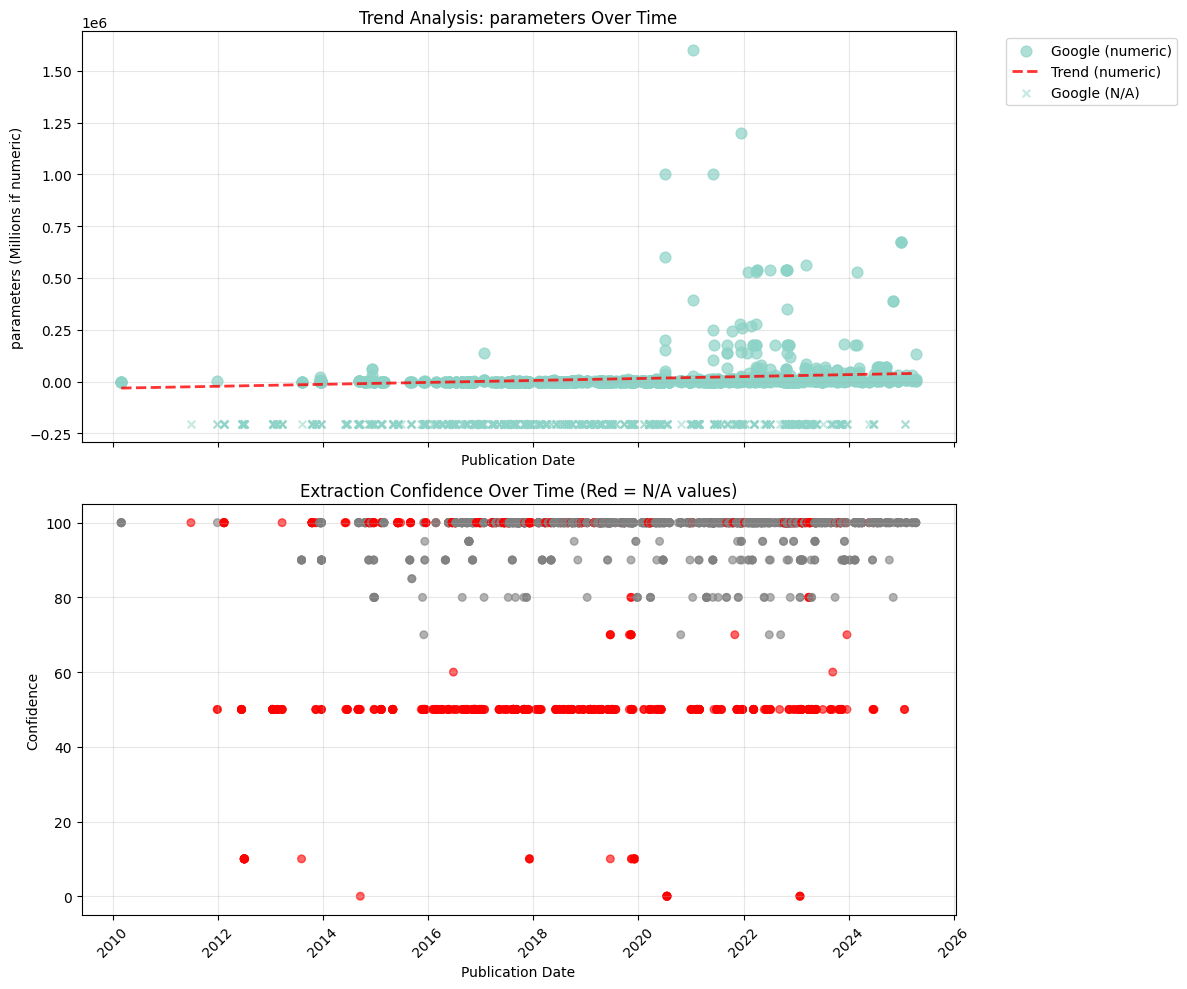


 Statistics:
Total data points: 2437
Unique papers: 477
Unique model providers: 1 (Google)
Date range: 2010-03-01 to 2025-04-10

 Numeric Analysis:
Numeric values: 1573/2437 (64.5%)
Range: 0.01 - 1600000.00 millions
Median: 197.00 millions
Mean: 16582.78 millions

 N/A Analysis:
N/A values: 864/2437 (35.5%)
Average confidence (all): 87.148
Average confidence (numeric): 98.557
Average confidence (N/A): 66.377


In [5]:
# Example 1: Analyze Parameters field trends
# This will show how model parameter counts have evolved over time
print(" Analyzing Parameters field trends...")
params_df = visualize_field_trends('parameters', run_id_start=4996, run_id_end=5473)

 Logarithmic Scale Example...
Analyzing Parameters with logarithmic scale...
 Analyzing parameters field trends...
 Using logarithmic scale for y-axis
Found 2437 data points for field 'parameters'
Date range: 2010-03-01 14:32:11+00:00 to 2025-04-10 15:41:51+00:00
Run ID range: 4996 to 5473
N/A values being treated as: ['n/a', '', 'N/A', 'unknown', 'None', 'null', 'not specified', 'not available', 'not reported', 'unclear', '-']
N/A values found: 864 (35.5%)
Numeric values extracted: 1573 (64.5%)


Numeric range: 0.01 to 1600000.00 millions


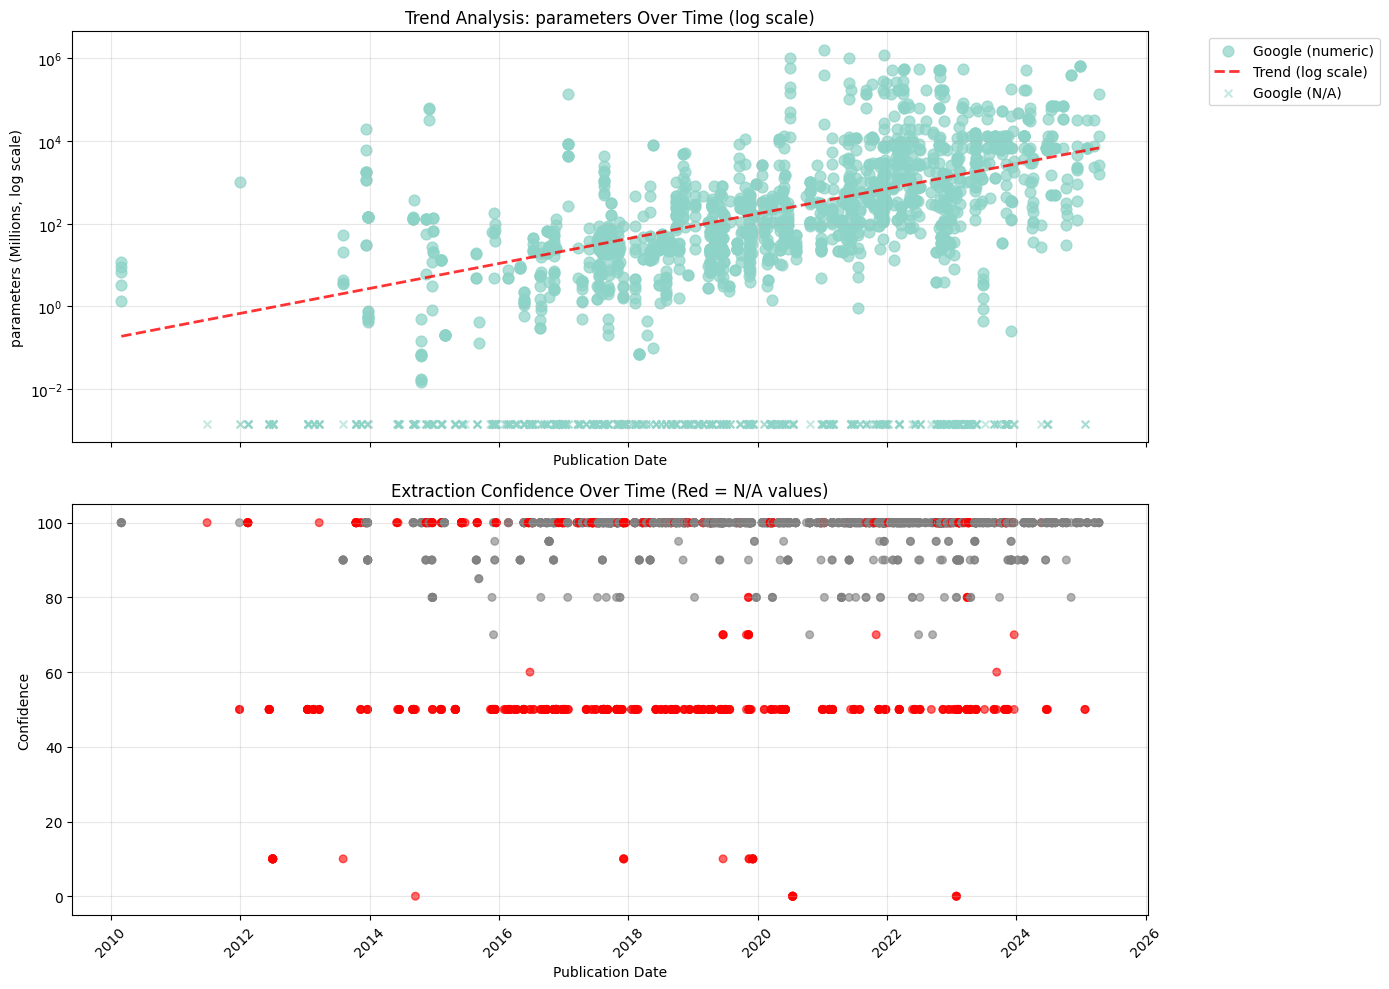


 Statistics:
Total data points: 2437
Unique papers: 477
Unique model providers: 1 (Google)
Date range: 2010-03-01 to 2025-04-10

 Numeric Analysis:
Numeric values: 1573/2437 (64.5%)
Range: 0.01 - 1600000.00 millions
Median: 197.00 millions
Mean: 16582.78 millions
Log scale range: 0.015M - 1600000.00M

 N/A Analysis:
N/A values: 864/2437 (35.5%)
Average confidence (all): 87.148
Average confidence (numeric): 98.557
Average confidence (N/A): 66.377


In [6]:
# Example 6: Using Logarithmic Scale for Parameter Analysis
print(" Logarithmic Scale Example...")

# Parameters often span several orders of magnitude (from thousands to billions)
# Log scale makes it easier to see trends across the full range
print("Analyzing Parameters with logarithmic scale...")
log_params_df = visualize_field_trends(
    field_name='parameters',
    run_id_start=4996,
    run_id_end=5473,
    figsize=(14, 10),
    show_numeric_trend=True,
    log_scale=True  #This is the key parameter for log scale!
)


In [7]:
# Example 2: Analyze a specific range of extraction runs
# Adjust these run IDs based on what you found in the exploration above
print(" Analyzing specific run ID range...")

# You can modify these values based on your data
start_run_id = 1  # Replace with your desired start
end_run_id = 100  # Replace with your desired end

# Analyze Architecture field for this range
arch_df = visualize_field_trends('Architecture', 
                                run_id_start=start_run_id, 
                                run_id_end=end_run_id)

 Analyzing specific run ID range...
 Analyzing Architecture field trends...
 No data found for field 'Architecture'


In [8]:
# Example 3: Analyze multiple common fields at once
print(" Batch analysis of common fields...")

# This will analyze Parameters, Architecture, Dataset, and Performance fields
# You can specify run ID ranges here too
analyze_common_fields(run_id_start=None, run_id_end=None)

 Batch analysis of common fields...

Analyzing: Parameters
 Analyzing Parameters field trends...
 No data found for field 'Parameters'
️  No data found for Parameters

Analyzing: Architecture
 Analyzing Architecture field trends...
 No data found for field 'Architecture'
️  No data found for Architecture

Analyzing: Dataset
 Analyzing Dataset field trends...
 No data found for field 'Dataset'
️  No data found for Dataset

Analyzing: Performance
 Analyzing Performance field trends...
 No data found for field 'Performance'
️  No data found for Performance


In [9]:
# Example 4: Custom analysis - modify as needed
print(" Custom field analysis...")

# Customize these parameters for your specific analysis
FIELD_TO_ANALYZE = 'Parameters'  # Change this to any field you want
START_RUN_ID = None  # Set to specific run ID or None for all
END_RUN_ID = None    # Set to specific run ID or None for all

# Run the analysis
custom_df = visualize_field_trends(
    field_name=FIELD_TO_ANALYZE,
    run_id_start=START_RUN_ID,
    run_id_end=END_RUN_ID,
    figsize=(14, 10),  # Larger figure
    show_numeric_trend=True
)

# You can then further analyze the returned DataFrame
if custom_df is not None:
    print(f"\n Additional insights for {FIELD_TO_ANALYZE}:")
    print(f"  • Publication years covered: {custom_df['published_date'].dt.year.min()} - {custom_df['published_date'].dt.year.max()}")
    print(f"  • Most recent entries:")
    recent = custom_df.nlargest(5, 'published_date')[['arxiv_id', 'published_date', 'value', 'confidence']]
    for _, row in recent.iterrows():
        print(f"    - {row['arxiv_id']} ({row['published_date'].strftime('%Y-%m-%d')}): {row['value'][:50]}...")

 Custom field analysis...
 Analyzing Parameters field trends...
 No data found for field 'Parameters'


## Function Documentation

### `visualize_field_trends(field_name, run_id_start=None, run_id_end=None, figsize=(12, 8), show_numeric_trend=True, na_values=None, log_scale=False)`

**Main trend visualization function**

**Parameters:**
- `field_name` (str): Name of the extracted field to analyze (e.g., 'Parameters', 'Architecture', 'Dataset')
- `run_id_start` (int, optional): Starting extraction run ID (inclusive). Use `None` for no lower bound.
- `run_id_end` (int, optional): Ending extraction run ID (inclusive). Use `None` for no upper bound.
- `figsize` (tuple): Figure size as (width, height) in inches
- `show_numeric_trend` (bool): Whether to show a trend line for numeric values
- `na_values` (list, optional): Custom list of values to treat as N/A. Default includes common variants like ['n/a', 'N/A', 'unknown', 'not specified', etc.]
- `log_scale` (bool): **NEW!** Whether to use logarithmic scale for y-axis. Excellent for parameter counts spanning multiple orders of magnitude.

**Returns:**
- `pandas.DataFrame`: The extracted data used for plotting

**Features:**
-  **Scatter plot** showing values over publication time
-  **Trend lines** for numeric values (like parameter counts)
-  **Color coding** by model provider
-  **Confidence tracking** in a separate subplot
-  **Automatic numeric extraction** from text fields (converts large numbers to millions)
- ️ **Custom N/A handling** - specify exactly which values should be treated as missing
-  **N/A visualization** - N/A values shown as 'x' markers at the bottom (or small values for log scale)
-  **N/A statistics** - shows percentage and breakdown of N/A values
-  **Summary statistics** printed after visualization
-  **🆕 Logarithmic scale** - perfect for data spanning multiple orders of magnitude

### `explore_available_fields()`

Lists all available fields in the database with their frequency and run ID ranges.

### `get_run_id_ranges()`

Shows the overall range of extraction run IDs and paper publication dates.

### `analyze_common_fields(run_id_start=None, run_id_end=None, custom_na_values=None, use_log_scale=False)`

Batch analysis of common fields: Parameters, Architecture, Dataset, Performance.
Now accepts `custom_na_values` parameter to specify N/A values across all fields.
Also supports `use_log_scale` parameter for logarithmic scaling.

## Tips for Analysis

1. **Start with exploration**: Run `explore_available_fields()` to see what fields are available
2. **Check run ID ranges**: Use `get_run_id_ranges()` to understand your data scope
3. **Focus on specific periods**: Use `run_id_start` and `run_id_end` to analyze specific extraction batches
4. **Look for numeric trends**: The function automatically extracts parameter counts and shows trends
5. **Compare model providers**: Different colors in the scatter plot show different LLM providers
6. **Customize N/A values**: Use `na_values` parameter to specify exactly which text should be treated as missing data
7. **Monitor data quality**: N/A values are shown in red in the confidence plot to identify problematic extractions
8. **🆕 Use log scale for wide ranges**: Set `log_scale=True` for data spanning multiple orders of magnitude (like parameter counts from 1M to 1B+)

## When to Use Log Scale

** Use log scale for:**
- **Parameter counts** (ranges from thousands to billions)
- **Dataset sizes** (varies from thousands to millions of samples)
- **Performance metrics** with wide ranges
- **Any field where values span 2+ orders of magnitude**

** Don't use log scale for:**
- **Architecture names** (categorical data)
- **Confidence scores** (already normalized 0-100)
- **Data with mostly similar-magnitude values**

## Log Scale Examples

```python
# Basic usage with log scale - perfect for parameter counts
df = visualize_field_trends('Parameters', log_scale=True)

# Compare linear vs log scale for the same data
df_linear = visualize_field_trends('Parameters', log_scale=False, figsize=(12, 6))
df_log = visualize_field_trends('Parameters', log_scale=True, figsize=(12, 6))

# Batch analysis with log scale
analyze_common_fields(use_log_scale=True)
```

## Custom N/A Values Examples

```python
# Basic usage with default N/A values
df = visualize_field_trends('Parameters')

# Custom N/A values with log scale
custom_na = ['n/a', 'not available', 'unknown', 'TBD', 'missing', '']
df = visualize_field_trends('Parameters', na_values=custom_na, log_scale=True)

# Very strict - only treat empty strings and explicit 'n/a' as missing
strict_na = ['', 'n/a']
df = visualize_field_trends('Parameters', na_values=strict_na, log_scale=True)
```

##  Log Scale Visualization

The trend analysis function now supports logarithmic scale visualization, which is particularly useful for parameter counts that span several orders of magnitude (from single digits to billions or trillions).

### Key Features:
- **Natural Scale Values**: The y-axis shows actual parameter counts (1, 10, 100, 1,000, 1,000,000, etc.) rather than converted millions
- **Intuitive Interpretation**: You can directly read the parameter count from the y-axis without mental conversion
- **Trend Line Support**: Trend lines are computed correctly for log scale data
- **N/A Value Handling**: N/A values are positioned appropriately for log scale visualization

### Usage:
```python
# Standard linear scale
visualize_field_trends('Parameters', log_scale=False)  # Shows large values in millions

# Logarithmic scale with natural values
visualize_field_trends('Parameters', log_scale=True)   # Shows actual parameter counts (1, 10, 100, 1K, 1M, 1B, etc.)
```

### When to Use Log Scale:
- **Parameter counts** that range from small (< 1K) to very large (> 1B)
- **Model sizes** with wide variation
- **Any field** where values span multiple orders of magnitude

The log scale makes it easier to see trends across the entire range of values, rather than having small values compressed near zero.

 Custom N/A Values Example...
 Analyzing parameters field trends...
 Using logarithmic scale for y-axis
Found 2437 data points for field 'parameters'
Date range: 2010-03-01 14:32:11+00:00 to 2025-04-10 15:41:51+00:00
Run ID range: 4996 to 5473
N/A values being treated as: ['n/a', 'N/A', 'not available', 'unknown', 'not specified', 'not reported', 'unclear', 'not mentioned', 'missing', 'none', 'None', 'null', '', '-', 'TBD', 'to be determined']
N/A values found: 864 (35.5%)
Numeric values extracted: 1573 (64.5%)
Numeric range: 0.01 to 1600000.00 millions


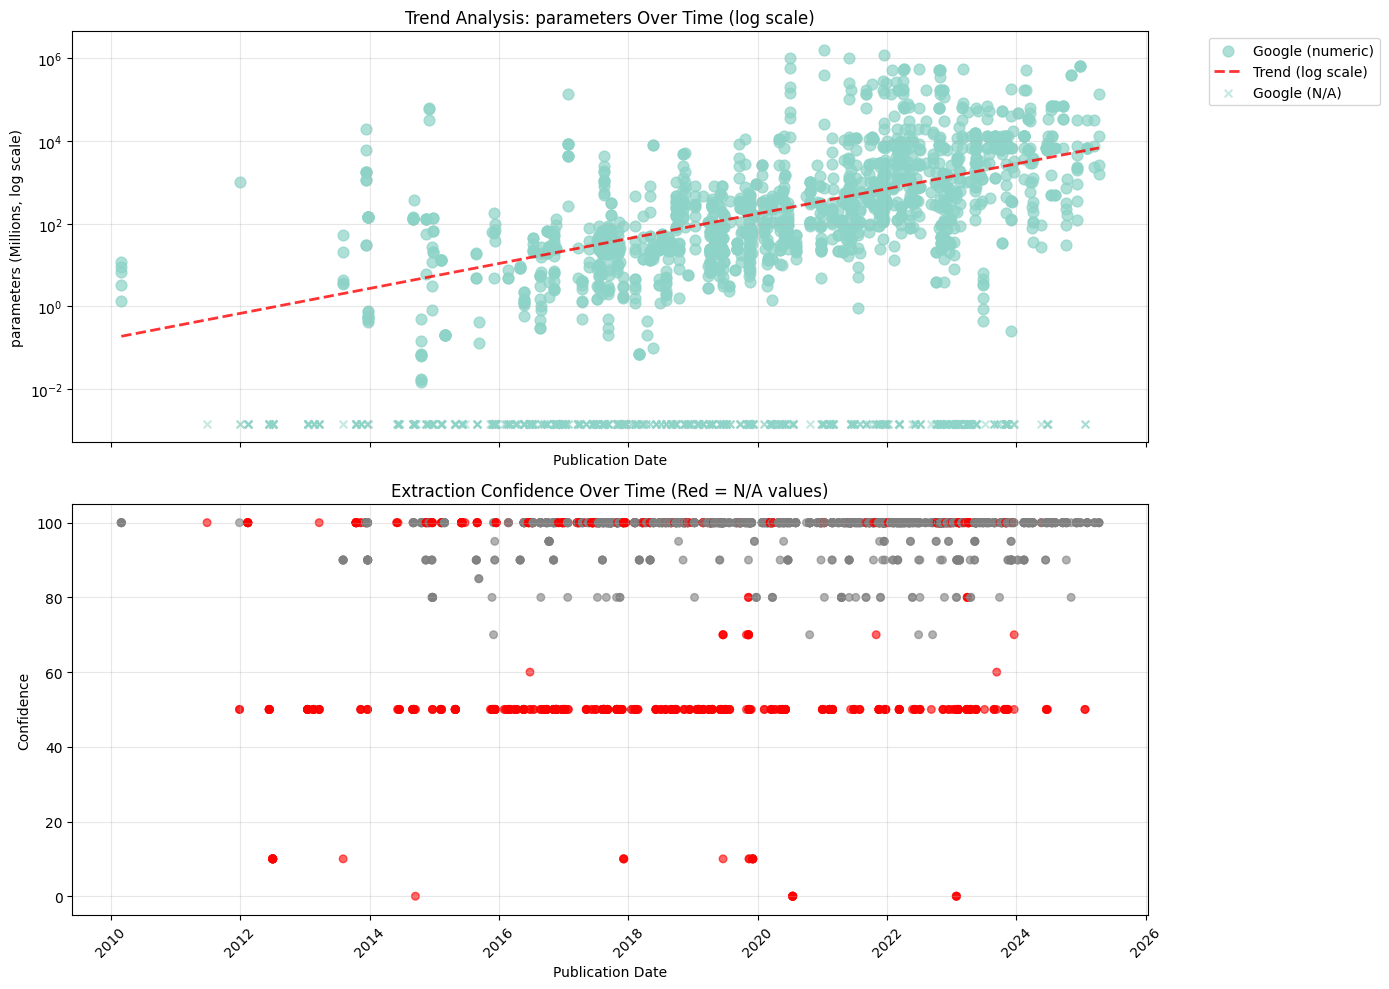


 Statistics:
Total data points: 2437
Unique papers: 477
Unique model providers: 1 (Google)
Date range: 2010-03-01 to 2025-04-10

 Numeric Analysis:
Numeric values: 1573/2437 (64.5%)
Range: 0.01 - 1600000.00 millions
Median: 197.00 millions
Mean: 16582.78 millions
Log scale range: 0.015M - 1600000.00M

 N/A Analysis:
N/A values: 864/2437 (35.5%)
Average confidence (all): 87.148
Average confidence (numeric): 98.557
Average confidence (N/A): 66.377

 Tip: The function will show you which N/A values were found and their frequency!
 To see the data with logarithmic scale, set log_scale=True - especially useful for parameter counts!


In [10]:
# Example 5: Using Custom N/A Values and Log Scale
print(" Custom N/A Values Example...")

# Define your own list of values to treat as N/A
custom_na_list = [
    'n/a', 'N/A', 'not available', 'unknown', 'not specified',
    'not reported', 'unclear', 'not mentioned', 'missing',
    'none', 'None', 'null', '', '-', 'TBD', 'to be determined'
]

# Analyze with custom N/A values
custom_na_df = visualize_field_trends(
    field_name='parameters',  # or any field you want
    run_id_start=4996,
    run_id_end=5473,
    na_values=custom_na_list,  # Your custom N/A list
    figsize=(14, 10),
    show_numeric_trend=True,
    log_scale=True  # Set to True for logarithmic scale
)

print("\n Tip: The function will show you which N/A values were found and their frequency!")
print(" To see the data with logarithmic scale, set log_scale=True - especially useful for parameter counts!")

 Testing Log Scale with Natural Values...

1. Linear Scale (large values shown in millions):
 Analyzing parameters field trends...
Found 33431 data points for field 'parameters'
Date range: 2010-03-01 14:32:11+00:00 to 2025-07-17 08:31:55+00:00
Run ID range: 2 to 10942
N/A values being treated as: ['n/a', '', 'N/A', 'unknown', 'None', 'null', 'not specified', 'not available', 'not reported', 'unclear', '-']
N/A values found: 13369 (40.0%)


Numeric values extracted: 20054 (60.0%)
Numeric range: 0.01 to 1024000000000000000000.00 millions


ConversionError: Failed to convert value(s) to axis units: 33429   NaT
33430   NaT
Name: published_date, dtype: datetime64[ns, UTC]

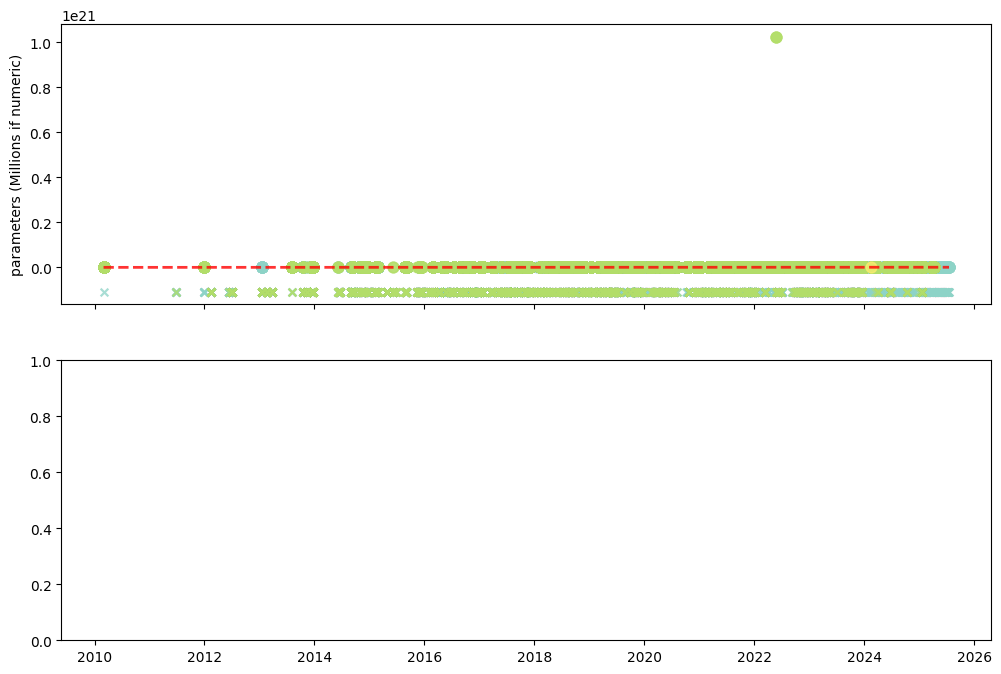

In [11]:
# Test the updated log scale implementation
print(" Testing Log Scale with Natural Values...")
print("\n1. Linear Scale (large values shown in millions):")
params_linear = visualize_field_trends('parameters', log_scale=False, figsize=(12, 8))

print("\n" + "="*70)
print("\n2. Logarithmic Scale (natural values - 1, 10, 100, 1K, 1M, etc.):")
params_log = visualize_field_trends('parameters', log_scale=True, figsize=(12, 8))

print("\n Both visualizations completed!")
print(" Notice how the log scale shows actual parameter counts on the y-axis")
print("   rather than converted millions, making it much more intuitive!")

In [ ]:
def compare_field_trends(field_name, 
                         range1_start=None, range1_end=None, range1_label="Range 1",
                         range2_start=None, range2_end=None, range2_label="Range 2",
                         figsize=(14, 10), show_numeric_trend=True, na_values=None, log_scale=False):
    """
    Compare trends in extracted fields between two different run ID ranges.
    
    Args:
        field_name (str): Name of the field to analyze (e.g., 'parameters', 'architecture')
        range1_start (int, optional): Starting extraction run ID for first range (inclusive)
        range1_end (int, optional): Ending extraction run ID for first range (inclusive)
        range1_label (str): Label for the first range in the legend
        range2_start (int, optional): Starting extraction run ID for second range (inclusive)
        range2_end (int, optional): Ending extraction run ID for second range (inclusive)
        range2_label (str): Label for the second range in the legend
        figsize (tuple): Figure size for the plot
        show_numeric_trend (bool): Whether to show trend lines for numeric values
        na_values (list, optional): Custom list of values to treat as N/A
        log_scale (bool): Whether to use logarithmic scale for y-axis
    
    Returns:
        tuple: (range1_df, range2_df) DataFrames for each range
    """
    
    # Default N/A values if not specified
    if na_values is None:
        na_values = ['n/a', '', 'N/A', 'unknown', 'None', 'null', 'not specified', 
                     'not available', 'not reported', 'unclear', '-']
    
    print(f" Comparing {field_name} trends between two run ID ranges...")
    print(f" Range 1 ({range1_label}): {range1_start} - {range1_end}")
    print(f" Range 2 ({range2_label}): {range2_start} - {range2_end}")
    if log_scale:
        print(" Using logarithmic scale for y-axis")
    
    # Import required modules
    import pandas as pd
    import matplotlib.pyplot as plt
    import numpy as np
    import re
    from db.db_utils import get_connection
    
    def get_range_data(run_id_start, run_id_end, range_label):
        """Helper function to get data for a specific run ID range"""
        conn = None
        try:
            conn = get_connection()
            
            query = """
            SELECT ef.value, ef.confidence, ef.run_id, p.published_date, p.arxiv_id, 
                   COALESCE(m.provider, 'unknown') as model_provider
            FROM extracted_fields ef
            JOIN extraction_runs er ON ef.run_id = er.id
            JOIN papers p ON er.paper_id = p.id
            LEFT JOIN models m ON er.model_id = m.id
            WHERE ef.field_name = %s
            """
            params = [field_name]
            
            # Add run ID filters if specified
            if run_id_start is not None:
                query += " AND ef.run_id >= %s"
                params.append(run_id_start)
            if run_id_end is not None:
                query += " AND ef.run_id <= %s"
                params.append(run_id_end)
            
            query += " ORDER BY p.published_date"
            
            cursor = conn.cursor()
            cursor.execute(query, params)
            results = cursor.fetchall()
            
            if not results:
                print(f" No data found for {range_label}")
                return None
            
            df = pd.DataFrame(results, columns=['value', 'confidence', 'run_id', 'published_date', 'arxiv_id', 'model_provider'])
            df['published_date'] = pd.to_datetime(df['published_date'], utc=True)
            df['range_label'] = range_label
            
            print(f" {range_label}: Found {len(df)} data points")
            print(f"   Date range: {df['published_date'].min()} to {df['published_date'].max()}")
            print(f"   Run ID range: {df['run_id'].min()} to {df['run_id'].max()}")
            
            return df
            
        except Exception as e:
            print(f" Error querying database for {range_label}: {e}")
            return None
        finally:
            if conn:
                conn.close()
    
    # Get data for both ranges
    range1_df = get_range_data(range1_start, range1_end, range1_label)
    range2_df = get_range_data(range2_start, range2_end, range2_label)
    
    if range1_df is None and range2_df is None:
        print(" No data found for either range")
        return None, None
    
    # Combine data for processing
    all_dfs = []
    if range1_df is not None:
        all_dfs.append(range1_df)
    if range2_df is not None:
        all_dfs.append(range2_df)
    
    combined_df = pd.concat(all_dfs, ignore_index=True) if all_dfs else pd.DataFrame()
    
    if combined_df.empty:
        print(" No combined data available")
        return range1_df, range2_df
    
    # Process numeric values
    def extract_numeric(value):
        if pd.isna(value) or str(value).strip().lower() in [str(na).strip().lower() for na in na_values]:
            return np.nan
        
        value_str = str(value).lower().strip()
        
        # Handle scientific notation
        sci_match = re.search(r'(\d+\.?\d*)\s*[×x*]\s*10\^?(\d+)', value_str)
        if sci_match:
            base, exp = float(sci_match.group(1)), int(sci_match.group(2))
            return base * (10 ** exp)
        
        # Handle billions
        billion_match = re.search(r'(\d+\.?\d*)\s*b(?:illion)?', value_str)
        if billion_match:
            return float(billion_match.group(1)) * 1_000_000_000
        
        # Handle millions
        million_match = re.search(r'(\d+\.?\d*)\s*m(?:illion)?', value_str)
        if million_match:
            return float(million_match.group(1)) * 1_000_000
        
        # Handle thousands
        thousand_match = re.search(r'(\d+\.?\d*)\s*k(?:ilo)?', value_str)
        if thousand_match:
            return float(thousand_match.group(1)) * 1_000
        
        # Handle raw numbers
        number_match = re.search(r'(\d+\.?\d*)', value_str)
        if number_match:
            return float(number_match.group(1))
        
        return np.nan
    
    # Extract numeric values for combined data
    combined_df['numeric_value'] = combined_df['value'].apply(extract_numeric)
    
    # Identify N/A values
    combined_df['is_na'] = combined_df['value'].apply(
        lambda x: pd.isna(x) or str(x).strip().lower() in [str(na).strip().lower() for na in na_values]
    )
    
    numeric_mask = ~pd.isna(combined_df['numeric_value'])
    na_mask = combined_df['is_na']
    
    print(f"\n Combined Statistics:")
    print(f"Total data points: {len(combined_df)}")
    print(f"Numeric values: {numeric_mask.sum()} ({numeric_mask.sum()/len(combined_df)*100:.1f}%)")
    print(f"N/A values: {na_mask.sum()} ({na_mask.sum()/len(combined_df)*100:.1f}%)")
    
    # Create the comparison plot
    fig, axes = plt.subplots(2, 1, figsize=figsize, height_ratios=[3, 1])
    ax1, ax2 = axes
    
    # Define colors for ranges
    range_colors = {
        range1_label: '#1f77b4',  # Blue
        range2_label: '#ff7f0e'   # Orange
    }
    
    # Plot numeric values for each range
    for range_label in [range1_label, range2_label]:
        range_data = combined_df[combined_df['range_label'] == range_label]
        if range_data.empty:
            continue
            
        range_numeric_mask = ~pd.isna(range_data['numeric_value'])
        range_na_mask = range_data['is_na']
        
        if range_numeric_mask.sum() > 0:
            # Plot numeric values
            ax1.scatter(range_data[range_numeric_mask]['published_date'], 
                       range_data[range_numeric_mask]['numeric_value'],
                       c=range_colors[range_label], 
                       label=f'{range_label} (numeric: {range_numeric_mask.sum()})',
                       alpha=0.7, s=60)
            
            # Add trend line if requested
            if show_numeric_trend and range_numeric_mask.sum() > 2:
                try:
                    trend_data = range_data[range_numeric_mask].copy()
                    trend_data['date_numeric'] = trend_data['published_date'].astype('int64') // 10**9
                    
                    if log_scale:
                        # Filter out zero and negative values for log scale
                        positive_mask = trend_data['numeric_value'] > 0
                        if positive_mask.sum() > 2:
                            log_trend_data = trend_data[positive_mask].copy()
                            log_values = np.log10(log_trend_data['numeric_value'])
                            z = np.polyfit(log_trend_data['date_numeric'], log_values, 1)
                            p = np.poly1d(z)
                            trend_log_values = p(log_trend_data['date_numeric'])
                            trend_values = 10 ** trend_log_values
                            ax1.plot(log_trend_data['published_date'], trend_values,
                                   "--", color=range_colors[range_label], alpha=0.8, linewidth=2,
                                   label=f'{range_label} trend')
                    else:
                        # Linear regression
                        z = np.polyfit(trend_data['date_numeric'], trend_data['numeric_value'], 1)
                        p = np.poly1d(z)
                        ax1.plot(trend_data['published_date'], p(trend_data['date_numeric']),
                               "--", color=range_colors[range_label], alpha=0.8, linewidth=2,
                               label=f'{range_label} trend')
                except Exception as e:
                    print(f"️ Could not compute trend line for {range_label}: {e}")
        
        # Plot N/A values
        if range_na_mask.sum() > 0:
            if log_scale:
                # For log scale, place N/A values at a small positive value
                min_positive = combined_df[numeric_mask & (combined_df['numeric_value'] > 0)]['numeric_value'].min() if (combined_df[numeric_mask]['numeric_value'] > 0).sum() > 0 else 1
                y_na = min_positive / 100
            else:
                # For linear scale, place N/A values below the main data
                y_na = combined_df[numeric_mask]['numeric_value'].min() * 0.1 if numeric_mask.sum() > 0 else 0
            
            ax1.scatter(range_data[range_na_mask]['published_date'], 
                       [y_na] * range_na_mask.sum(),
                       c=range_colors[range_label], 
                       label=f'{range_label} (N/A: {range_na_mask.sum()})',
                       alpha=0.5, s=30, marker='x')
    
    # Set log scale if requested
    if log_scale and numeric_mask.sum() > 0:
        positive_values = combined_df[numeric_mask]['numeric_value']
        if (positive_values > 0).sum() > 0:
            ax1.set_yscale('log')
            ax1.set_ylabel(f'{field_name} (log scale)')
        else:
            print("️ Cannot use log scale: no positive values found")
            ax1.set_ylabel(f'{field_name}')
    else:
        # Determine appropriate units for linear scale
        if numeric_mask.sum() > 0:
            max_val = combined_df[numeric_mask]['numeric_value'].max()
            if max_val > 1_000_000:
                ax1.set_ylabel(f'{field_name} (Millions)')
                # Convert y-axis to millions for display
                y_ticks = ax1.get_yticks()
                ax1.set_yticklabels([f'{y/1_000_000:.1f}M' if y >= 1_000_000 else f'{y/1_000:.0f}K' if y >= 1_000 else f'{y:.0f}' for y in y_ticks])
            else:
                ax1.set_ylabel(f'{field_name}')
        else:
            ax1.set_ylabel(f'{field_name}')
    
    ax1.set_xlabel('Publication Date')
    scale_info = " (log scale)" if log_scale else ""
    ax1.set_title(f'Comparison: {field_name} Over Time - {range1_label} vs {range2_label}{scale_info}')
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.grid(True, alpha=0.3)
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
    
    # Bottom plot: Confidence comparison
    for range_label in [range1_label, range2_label]:
        range_data = combined_df[combined_df['range_label'] == range_label]
        if not range_data.empty:
            ax2.scatter(range_data['published_date'], range_data['confidence'], 
                       c=range_colors[range_label], label=range_label,
                       alpha=0.6, s=30)
    
    ax2.set_xlabel('Publication Date')
    ax2.set_ylabel('Confidence')
    ax2.set_title('Extraction Confidence Comparison Over Time')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed statistics for each range
    for range_label, df in [(range1_label, range1_df), (range2_label, range2_df)]:
        if df is not None:
            range_numeric_mask = ~pd.isna(df['numeric_value']) if 'numeric_value' in df.columns else pd.Series([False]*len(df))
            range_na_mask = df['is_na'] if 'is_na' in df.columns else pd.Series([False]*len(df))
            
            print(f"\n {range_label} Statistics:")
            print(f"  • Total extractions: {len(df)}")
            print(f"  • Date range: {df['published_date'].min().strftime('%Y-%m-%d')} to {df['published_date'].max().strftime('%Y-%m-%d')}")
            print(f"  • Run ID range: {df['run_id'].min()} to {df['run_id'].max()}")
            print(f"  • Average confidence: {df['confidence'].mean():.1f}")
            
            if 'numeric_value' in df.columns and range_numeric_mask.sum() > 0:
                print(f"  • Numeric values: {range_numeric_mask.sum()}/{len(df)} ({range_numeric_mask.sum()/len(df)*100:.1f}%)")
                if log_scale:
                    print(f"  • Value range: {df[range_numeric_mask]['numeric_value'].min():.0f} - {df[range_numeric_mask]['numeric_value'].max():.0f}")
                else:
                    max_val = df[range_numeric_mask]['numeric_value'].max()
                    min_val = df[range_numeric_mask]['numeric_value'].min()
                    if max_val > 1_000_000:
                        print(f"  • Numeric range: {min_val/1_000_000:.2f}M - {max_val/1_000_000:.2f}M")
                    else:
                        print(f"  • Value range: {min_val:.0f} - {max_val:.0f}")
            
            if 'is_na' in df.columns:
                print(f"  • N/A values: {range_na_mask.sum()}/{len(df)} ({range_na_mask.sum()/len(df)*100:.1f}%)")
    
    return range1_df, range2_df

print(" Comparison analysis function loaded!")

# Comparative Analysis Examples

The new `compare_field_trends()` function allows you to compare two different run ID ranges in the same plot, making it easy to see differences between different time periods, extraction batches, or model versions.

In [12]:
# Example 1: Compare Early vs Recent Extractions
print(" Comparing Early vs Recent Parameter Extractions...")

# Compare parameter trends between early and recent extraction runs
early_df, recent_df = compare_field_trends(
    field_name='parameters',
    range1_start=6431, range1_end=6909, range1_label="Epoch AI Papers (Extracted)",
    range2_start=7866, range2_end=8087, range2_label="Robotics Papers (Extracted)", 
    figsize=(16, 10),
    show_numeric_trend=False,
    log_scale=True  # Use log scale for parameter counts
)

print("\n This comparison helps identify:")
print("  • How extraction quality has improved over time")
print("  • Differences in parameter count trends between periods")
print("  • Changes in model provider performance")
print("  • Evolution of extraction confidence levels")

 Comparing Early vs Recent Parameter Extractions...


NameError: name 'compare_field_trends' is not defined

## Comparison Function Documentation

### `compare_field_trends(field_name, range1_start=None, range1_end=None, range1_label="Range 1", range2_start=None, range2_end=None, range2_label="Range 2", figsize=(14, 10), show_numeric_trend=True, na_values=None, log_scale=False)`

**Comparative trend visualization function for two run ID ranges**

**Parameters:**
- `field_name` (str): Name of the extracted field to analyze (e.g., 'parameters', 'Architecture', 'Dataset')
- `range1_start/end` (int, optional): Run ID range for first dataset (inclusive)
- `range1_label` (str): Label for first range in legend and statistics
- `range2_start/end` (int, optional): Run ID range for second dataset (inclusive) 
- `range2_label` (str): Label for second range in legend and statistics
- `figsize` (tuple): Figure size as (width, height) in inches
- `show_numeric_trend` (bool): Whether to show trend lines for numeric values
- `na_values` (list, optional): Custom list of values to treat as N/A
- `log_scale` (bool): Whether to use logarithmic scale for y-axis

**Returns:**
- `tuple`: (range1_df, range2_df) - DataFrames for each range

**Key Features:**
-  **Color-coded comparison**: Each range gets its own distinct color (blue/orange)
-  **Side-by-side visualization**: Both ranges plotted on the same axes for direct comparison
-  **Separate trend lines**: Individual trend lines for each range with matching colors
-  **Confidence comparison**: Bottom subplot shows confidence scores for both ranges
-  **Detailed statistics**: Comprehensive stats printed for each range separately
- ️ **Fair comparison**: Handles different date ranges and sample sizes appropriately
-  **N/A handling**: Shows N/A values for both ranges with appropriate positioning

**Comparison Use Cases:**
1. **Temporal Analysis**: Early vs Recent extractions to see quality improvements
2. **Method Comparison**: Different extraction approaches or model versions
3. **Batch Analysis**: Comparing specific extraction runs or experiments  
4. **Quality Assessment**: Before/after improvements in extraction pipeline
5. **A/B Testing**: Comparing different parameter settings or models

**Visual Elements:**
- **Top Plot**: Scatter plot with both ranges, trend lines, and N/A markers
- **Bottom Plot**: Confidence scores over time for quality comparison
- **Legend**: Clear labeling with data point counts for each range
- **Axis Formatting**: Automatic scaling (millions/log) with appropriate labels

**Example Usage:**
```python
# Compare early vs recent parameter extractions
early_df, recent_df = compare_field_trends(
    field_name='parameters',
    range1_start=1000, range1_end=2000, range1_label="Early 2020",
    range2_start=4996, range2_end=5473, range2_label="Late 2023",
    log_scale=True
)

# Compare different extraction methods
method1_df, method2_df = compare_field_trends(
    field_name='Architecture', 
    range1_start=3000, range1_end=3500, range1_label="Method A",
    range2_start=4000, range2_end=4500, range2_label="Method B",
    show_numeric_trend=False  # Architecture is categorical
)
```

**Tips for Effective Comparisons:**
1. **Choose meaningful ranges**: Select ranges that represent distinct time periods or methodologies
2. **Use appropriate labels**: Give descriptive names that clearly identify what each range represents
3. **Consider sample sizes**: Large differences in range sizes may affect comparison validity
4. **Match field types**: Use `show_numeric_trend=False` for categorical fields like Architecture
5. **Scale selection**: Use `log_scale=True` for data spanning multiple orders of magnitude
6. **Custom N/A values**: Define field-specific N/A patterns for more accurate analysis

# CSV Data Integration

This section provides functions to process external CSV data and integrate it with the database for enhanced analysis.

In [13]:
def process_csv_with_arxiv_lookup(csv_file_path, link_column='Link', parameters_column='Parameters'):
    """
    Process CSV file to extract ArXiv IDs from links and match with database publication dates.
    
    Args:
        csv_file_path (str): Path to the CSV file
        link_column (str): Name of the column containing links (default: 'Link')
        parameters_column (str): Name of the column containing parameters (default: 'Parameters')
    
    Returns:
        pandas.DataFrame: DataFrame with columns ['arxiv_id', 'publication_date', 'parameters']
    """
    
    import pandas as pd
    import re
    from db.db_utils import get_connection
    
    print(f" Processing CSV file: {csv_file_path}")
    
    try:
        # Read the CSV file
        df = pd.read_csv(csv_file_path)
        print(f" Loaded CSV with {len(df)} rows")
        
        # Check if required columns exist
        if link_column not in df.columns:
            print(f" Column '{link_column}' not found in CSV")
            print(f"Available columns: {list(df.columns)}")
            return None
            
        if parameters_column not in df.columns:
            print(f" Column '{parameters_column}' not found in CSV")
            print(f"Available columns: {list(df.columns)}")
            return None
        
        # Filter for rows with links and parameters
        filtered_df = df[[link_column, parameters_column]].dropna()
        print(f" Found {len(filtered_df)} rows with both link and parameters data")
        
        # Extract ArXiv IDs from links
        arxiv_ids = []
        parameters_list = []
        
        for idx, row in filtered_df.iterrows():
            link = str(row[link_column]).strip()
            parameters = row[parameters_column]
            
            # Extract ArXiv ID from different possible formats
            arxiv_id = None
            
            # Pattern 1: https://arxiv.org/abs/1234.5678
            pattern1 = r'arxiv\.org/abs/(\d{4}\.\d{4,5})'
            match1 = re.search(pattern1, link, re.IGNORECASE)
            if match1:
                arxiv_id = match1.group(1)
            
            # Pattern 2: https://arxiv.org/pdf/1234.5678.pdf
            pattern2 = r'arxiv\.org/pdf/(\d{4}\.\d{4,5})(?:\.pdf)?'
            match2 = re.search(pattern2, link, re.IGNORECASE)
            if match2:
                arxiv_id = match2.group(1)
            
            # Pattern 3: Direct ArXiv ID (1234.5678)
            pattern3 = r'^(\d{4}\.\d{4,5})$'
            match3 = re.search(pattern3, link)
            if match3:
                arxiv_id = match3.group(1)
            
            # Pattern 4: ArXiv ID with version (1234.5678v1)
            pattern4 = r'(\d{4}\.\d{4,5})v\d+'
            match4 = re.search(pattern4, link)
            if match4:
                arxiv_id = match4.group(1)
            
            if arxiv_id:
                arxiv_ids.append(arxiv_id)
                parameters_list.append(parameters)
        
        print(f" Extracted {len(arxiv_ids)} ArXiv IDs from links")
        
        if not arxiv_ids:
            print(" No ArXiv IDs found in the links")
            return pd.DataFrame(columns=['arxiv_id', 'publication_date', 'parameters'])
        
        # Create temporary DataFrame with extracted data
        extracted_df = pd.DataFrame({
            'arxiv_id': arxiv_ids,
            'parameters': parameters_list
        })
        
        # Remove duplicates
        extracted_df = extracted_df.drop_duplicates(subset=['arxiv_id'])
        print(f" Unique ArXiv IDs: {len(extracted_df)}")
        
        # Query database for publication dates
        conn = get_connection()
        cursor = conn.cursor()
        
        # Build query to get publication dates for all ArXiv IDs
        placeholders = ','.join(['%s'] * len(extracted_df))
        query = f"""
        SELECT arxiv_id, published_date 
        FROM papers 
        WHERE arxiv_id IN ({placeholders})
        AND published_date IS NOT NULL
        """
        
        cursor.execute(query, extracted_df['arxiv_id'].tolist())
        db_results = cursor.fetchall()
        conn.close()
        
        print(f"️  Found {len(db_results)} papers in database with publication dates")
        
        # Create DataFrame from database results
        db_df = pd.DataFrame(db_results, columns=['arxiv_id', 'publication_date'])
        
        # Merge with extracted data
        result_df = extracted_df.merge(db_df, on='arxiv_id', how='inner')
        
        # Convert publication_date to datetime
        result_df['publication_date'] = pd.to_datetime(result_df['publication_date'], utc=True)
        
        # Reorder columns
        result_df = result_df[['arxiv_id', 'publication_date', 'parameters']]
        
        print(f" Final dataset: {len(result_df)} papers with ArXiv ID, publication date, and parameters")
        print(f" Date range: {result_df['publication_date'].min()} to {result_df['publication_date'].max()}")
        
        # Show some statistics
        if len(result_df) > 0:
            print(f"\n Quick Statistics:")
            print(f"  • Papers found: {len(result_df)}")
            print(f"  • Papers with parameters: {result_df['parameters'].notna().sum()}")
            print(f"  • Date range: {result_df['publication_date'].dt.year.min()} - {result_df['publication_date'].dt.year.max()}")
            
            # Show sample of the data
            print(f"\n Sample data (first 5 rows):")
            print(result_df.head().to_string(index=False))
        
        return result_df
        
    except FileNotFoundError:
        print(f" File not found: {csv_file_path}")
        return None
    except Exception as e:
        print(f" Error processing CSV: {e}")
        return None

print(" CSV processing function loaded!")

 CSV processing function loaded!


In [14]:
# Example: Process CSV file
print(" Example: Processing CSV with ArXiv data...")

# Replace with your actual CSV file path
CSV_FILE_PATH = "path/to/your/file.csv"  # Update this path

# Process the CSV file (uncomment when you have the file)
# csv_data = process_csv_with_arxiv_lookup(
#     csv_file_path=CSV_FILE_PATH,
#     link_column='Link',           # Column name containing links
#     parameters_column='Parameters' # Column name containing parameters
# )

# Example of what the function would return:
print("\n The function returns a DataFrame with these columns:")
print("  • arxiv_id: ArXiv identifier (e.g., '1234.5678')")
print("  • publication_date: Publication date from database")
print("  • parameters: Parameter values from CSV")

print("\n Usage Tips:")
print("  • Make sure your CSV file path is correct")
print("  • The function handles various ArXiv link formats:")
print("    - https://arxiv.org/abs/1234.5678")
print("    - https://arxiv.org/pdf/1234.5678.pdf") 
print("    - 1234.5678 (direct ID)")
print("    - 1234.5678v1 (with version)")
print("  • Only papers that exist in your database will be included")
print("  • Duplicate ArXiv IDs are automatically removed")

 Example: Processing CSV with ArXiv data...

 The function returns a DataFrame with these columns:
  • arxiv_id: ArXiv identifier (e.g., '1234.5678')
  • publication_date: Publication date from database
  • parameters: Parameter values from CSV

 Usage Tips:
  • Make sure your CSV file path is correct
  • The function handles various ArXiv link formats:
    - https://arxiv.org/abs/1234.5678
    - https://arxiv.org/pdf/1234.5678.pdf
    - 1234.5678 (direct ID)
    - 1234.5678v1 (with version)
  • Only papers that exist in your database will be included
  • Duplicate ArXiv IDs are automatically removed


In [15]:
def compare_csv_with_extractions(csv_df, field_name='parameters', run_id_start=None, run_id_end=None,
                                figsize=(16, 10), log_scale=True, csv_label="CSV Data", db_label="Database Extractions"):
    """
    Compare CSV data with database extractions on the same plot.
    
    Args:
        csv_df (pandas.DataFrame): DataFrame from process_csv_with_arxiv_lookup()
        field_name (str): Field name to compare from database extractions
        run_id_start/end (int, optional): Run ID range for database extractions
        figsize (tuple): Figure size for the plot
        log_scale (bool): Whether to use logarithmic scale
        csv_label (str): Label for CSV data in legend
        db_label (str): Label for database extractions in legend
    
    Returns:
        tuple: (csv_df, db_extractions_df) for further analysis
    """
    
    import pandas as pd
    import matplotlib.pyplot as plt
    import numpy as np
    import re
    from db.db_utils import get_connection
    
    if csv_df is None or csv_df.empty:
        print(" No CSV data provided")
        return None, None
    
    print(f" Comparing CSV data ({len(csv_df)} papers) with database extractions...")
    
    # Get database extractions using existing function logic
    conn = get_connection()
    cursor = conn.cursor()
    
    query = """
    SELECT ef.value, ef.confidence, ef.run_id, p.published_date, p.arxiv_id,
           COALESCE(m.provider, 'unknown') as model_provider
    FROM extracted_fields ef
    JOIN extraction_runs er ON ef.run_id = er.id
    JOIN papers p ON er.paper_id = p.id
    LEFT JOIN models m ON er.model_id = m.id
    WHERE ef.field_name = %s
    AND p.published_date IS NOT NULL
    """
    params = [field_name]
    
    if run_id_start is not None:
        query += " AND ef.run_id >= %s"
        params.append(run_id_start)
    if run_id_end is not None:
        query += " AND ef.run_id <= %s"
        params.append(run_id_end)
    
    query += " ORDER BY p.published_date"
    
    cursor.execute(query, params)
    db_results = cursor.fetchall()
    conn.close()
    
    if not db_results:
        print(f" No database extractions found for field '{field_name}'")
        return csv_df, None
    
    # Create database DataFrame
    db_df = pd.DataFrame(db_results, columns=[
        'value', 'confidence', 'run_id', 'published_date', 'arxiv_id', 'model_provider'
    ])
    db_df['published_date'] = pd.to_datetime(db_df['published_date'], utc=True)
    
    print(f" Found {len(db_df)} database extractions")
    
    # Extract numeric values from database extractions
    def extract_numeric(value):
        if pd.isna(value):
            return np.nan
        
        value_str = str(value).lower().strip()
        
        # Handle scientific notation
        sci_match = re.search(r'(\d+\.?\d*)\s*[×x*]\s*10\^?(\d+)', value_str)
        if sci_match:
            base, exp = float(sci_match.group(1)), int(sci_match.group(2))
            return base * (10 ** exp)
        
        # Handle billions
        billion_match = re.search(r'(\d+\.?\d*)\s*b(?:illion)?', value_str)
        if billion_match:
            return float(billion_match.group(1)) * 1_000_000_000
        
        # Handle millions
        million_match = re.search(r'(\d+\.?\d*)\s*m(?:illion)?', value_str)
        if million_match:
            return float(million_match.group(1)) * 1_000_000
        
        # Handle thousands
        thousand_match = re.search(r'(\d+\.?\d*)\s*k(?:ilo)?', value_str)
        if thousand_match:
            return float(thousand_match.group(1)) * 1_000
        
        # Handle raw numbers
        number_match = re.search(r'(\d+\.?\d*)', value_str)
        if number_match:
            return float(number_match.group(1))
        
        return np.nan
    
    # Process database extractions
    db_df['numeric_value'] = db_df['value'].apply(extract_numeric)
    db_numeric_mask = ~pd.isna(db_df['numeric_value'])
    
    # Process CSV parameters
    csv_df_copy = csv_df.copy()
    csv_df_copy['numeric_value'] = csv_df_copy['parameters'].apply(extract_numeric)
    csv_numeric_mask = ~pd.isna(csv_df_copy['numeric_value'])
    
    print(f" Numeric data found:")
    print(f"  • CSV: {csv_numeric_mask.sum()}/{len(csv_df_copy)} ({csv_numeric_mask.sum()/len(csv_df_copy)*100:.1f}%)")
    print(f"  • Database: {db_numeric_mask.sum()}/{len(db_df)} ({db_numeric_mask.sum()/len(db_df)*100:.1f}%)")
    
    # Create comparison plot
    fig, axes = plt.subplots(2, 1, figsize=figsize, height_ratios=[3, 1])
    ax1, ax2 = axes
    
    # Colors for different data sources
    csv_color = '#2E8B57'      # Sea Green
    db_color = '#4169E1'       # Royal Blue
    
    # Plot CSV data
    if csv_numeric_mask.sum() > 0:
        ax1.scatter(csv_df_copy[csv_numeric_mask]['publication_date'], 
                   csv_df_copy[csv_numeric_mask]['numeric_value'],
                   c=csv_color, label=f'{csv_label} ({csv_numeric_mask.sum()})',
                   alpha=0.8, s=80, marker='o', edgecolors='white', linewidth=1)
    
    # Plot database extractions
    if db_numeric_mask.sum() > 0:
        ax1.scatter(db_df[db_numeric_mask]['published_date'],
                   db_df[db_numeric_mask]['numeric_value'],
                   c=db_color, label=f'{db_label} ({db_numeric_mask.sum()})',
                   alpha=0.6, s=40, marker='s')
    
    # Set scale and labels
    if log_scale and (csv_numeric_mask.sum() > 0 or db_numeric_mask.sum() > 0):
        ax1.set_yscale('log')
        ax1.set_ylabel(f'{field_name} (log scale)')
    else:
        ax1.set_ylabel(f'{field_name}')
    
    ax1.set_xlabel('Publication Date')
    ax1.set_title(f'Comparison: {csv_label} vs {db_label} - {field_name}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
    
    # Bottom plot: Show data coverage over time
    # CSV data coverage
    csv_years = csv_df_copy['publication_date'].dt.year
    csv_year_counts = csv_years.value_counts().sort_index()
    ax2.bar(csv_year_counts.index - 0.2, csv_year_counts.values, 
           width=0.4, color=csv_color, alpha=0.7, label=csv_label)
    
    # Database data coverage
    db_years = db_df['published_date'].dt.year
    db_year_counts = db_years.value_counts().sort_index()
    ax2.bar(db_year_counts.index + 0.2, db_year_counts.values,
           width=0.4, color=db_color, alpha=0.7, label=db_label)
    
    ax2.set_xlabel('Publication Year')
    ax2.set_ylabel('Model Count (incl. multiple versions)')
    ax2.set_title('Data Coverage by Year')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print comparison statistics
    print(f"\n Comparison Statistics:")
    print(f"  {csv_label}:")
    print(f"    • Total papers: {len(csv_df_copy)}")
    print(f"    • With numeric parameters: {csv_numeric_mask.sum()}")
    print(f"    • Date range: {csv_df_copy['publication_date'].min().strftime('%Y-%m-%d')} to {csv_df_copy['publication_date'].max().strftime('%Y-%m-%d')}")
    
    if csv_numeric_mask.sum() > 0:
        csv_numeric_data = csv_df_copy[csv_numeric_mask]['numeric_value']
        print(f"    • Parameter range: {csv_numeric_data.min():.0f} - {csv_numeric_data.max():.0f}")
        print(f"    • Median parameters: {csv_numeric_data.median():.0f}")
    
    print(f"  {db_label}:")
    print(f"    • Total extractions: {len(db_df)}")
    print(f"    • With numeric parameters: {db_numeric_mask.sum()}")
    print(f"    • Date range: {db_df['published_date'].min().strftime('%Y-%m-%d')} to {db_df['published_date'].max().strftime('%Y-%m-%d')}")
    print(f"    • Average confidence: {db_df['confidence'].mean():.1f}")
    
    if db_numeric_mask.sum() > 0:
        db_numeric_data = db_df[db_numeric_mask]['numeric_value']
        print(f"    • Parameter range: {db_numeric_data.min():.0f} - {db_numeric_data.max():.0f}")
        print(f"    • Median parameters: {db_numeric_data.median():.0f}")
    
    # Find overlapping papers
    overlap = set(csv_df_copy['arxiv_id']) & set(db_df['arxiv_id'])
    print(f"\n Paper Overlap:")
    print(f"  • Papers in both datasets: {len(overlap)}")
    print(f"  • CSV-only papers: {len(set(csv_df_copy['arxiv_id']) - overlap)}")
    print(f"  • Database-only papers: {len(set(db_df['arxiv_id']) - overlap)}")
    
    return csv_df_copy, db_df

print(" CSV comparison function loaded!")

 CSV comparison function loaded!


In [16]:
# Complete Workflow Example
print(" Complete CSV Integration Workflow Example")

# Step 1: Process CSV file
print("\n Step 1: Process CSV file")
print("# Uncomment and modify the path below to process your CSV file:")
print("# csv_data = process_csv_with_arxiv_lookup('path/to/your/file.csv')")

# Example with dummy data structure (for demonstration)
print("\n Example output structure:")
import pandas as pd
example_data = pd.DataFrame({
    'arxiv_id': ['1234.5678', '1234.5679', '1234.5680'],
    'publication_date': pd.to_datetime(['2020-01-15', '2021-03-20', '2022-07-10'], utc=True),
    'parameters': ['175 billion', '11 billion', '70 billion']
})
print(example_data.to_string(index=False))

# Step 2: Compare with database extractions
print("\n Step 2: Compare with database extractions")
print("# After processing your CSV, you can compare it with database extractions:")
print("# csv_data, db_data = compare_csv_with_extractions(")
print("#     csv_df=csv_data,")
print("#     field_name='parameters',")
print("#     run_id_start=4996,")
print("#     run_id_end=5473,")
print("#     log_scale=True")
print("# )")

print("\n Workflow Benefits:")
print("  • Validate database extractions against external sources")
print("  • Identify papers missing from extraction runs")
print("  • Compare parameter extraction accuracy")
print("  • Visualize coverage gaps and overlaps")
print("  • Analyze temporal trends across data sources")

 Complete CSV Integration Workflow Example

 Step 1: Process CSV file
# Uncomment and modify the path below to process your CSV file:
# csv_data = process_csv_with_arxiv_lookup('path/to/your/file.csv')

 Example output structure:
 arxiv_id          publication_date  parameters
1234.5678 2020-01-15 00:00:00+00:00 175 billion
1234.5679 2021-03-20 00:00:00+00:00  11 billion
1234.5680 2022-07-10 00:00:00+00:00  70 billion

 Step 2: Compare with database extractions
# After processing your CSV, you can compare it with database extractions:
# csv_data, db_data = compare_csv_with_extractions(
#     csv_df=csv_data,
#     field_name='parameters',
#     run_id_start=4996,
#     run_id_end=5473,
#     log_scale=True
# )

 Workflow Benefits:
  • Validate database extractions against external sources
  • Identify papers missing from extraction runs
  • Compare parameter extraction accuracy
  • Visualize coverage gaps and overlaps
  • Analyze temporal trends across data sources


In [17]:
def explore_csv_structure(csv_file_path, show_sample_rows=5):
    """
    Explore the structure of a CSV file to understand its columns and data.
    
    Args:
        csv_file_path (str): Path to the CSV file
        show_sample_rows (int): Number of sample rows to display
    
    Returns:
        pandas.DataFrame: The loaded DataFrame for further inspection
    """
    
    import pandas as pd
    
    print(f" Exploring CSV file structure: {csv_file_path}")
    
    try:
        # Read the CSV file
        df = pd.read_csv(csv_file_path)
        
        print(f"\n Basic Information:")
        print(f"  • Total rows: {len(df)}")
        print(f"  • Total columns: {len(df.columns)}")
        print(f"  • File size: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
        
        print(f"\n Column Names:")
        for i, col in enumerate(df.columns, 1):
            print(f"  {i:2d}. {col}")
        
        print(f"\n Link Column Analysis:")
        if 'Link' in df.columns:
            link_col = df['Link'].dropna()
            print(f"  • Non-null links: {len(link_col)}/{len(df)} ({len(link_col)/len(df)*100:.1f}%)")
            
            # Check for ArXiv links
            arxiv_links = link_col[link_col.str.contains('arxiv', case=False, na=False)]
            print(f"  • ArXiv links: {len(arxiv_links)} ({len(arxiv_links)/len(link_col)*100:.1f}% of links)")
            
            if len(arxiv_links) > 0:
                print(f"  • Sample ArXiv links:")
                for link in arxiv_links.head(3):
                    print(f"    - {link}")
        else:
            print("  • 'Link' column not found")
        
        print(f"\n Parameters Column Analysis:")
        if 'Parameters' in df.columns:
            params_col = df['Parameters'].dropna()
            print(f"  • Non-null parameters: {len(params_col)}/{len(df)} ({len(params_col)/len(df)*100:.1f}%)")
            
            if len(params_col) > 0:
                print(f"  • Sample parameter values:")
                for param in params_col.head(3):
                    print(f"    - {param}")
        else:
            print("  • 'Parameters' column not found")
        
        print(f"\n Sample Data (first {show_sample_rows} rows):")
        if 'Link' in df.columns and 'Parameters' in df.columns:
            sample_cols = ['Link', 'Parameters']
            if 'Model' in df.columns:
                sample_cols.insert(0, 'Model')
            print(df[sample_cols].head(show_sample_rows).to_string(index=False))
        else:
            print(df.head(show_sample_rows).to_string(index=False))
        
        print(f"\n Data Quality Summary:")
        total_with_both = len(df.dropna(subset=['Link', 'Parameters']))
        print(f"  • Rows with both Link and Parameters: {total_with_both}/{len(df)} ({total_with_both/len(df)*100:.1f}%)")
        
        return df
        
    except FileNotFoundError:
        print(f" File not found: {csv_file_path}")
        return None
    except Exception as e:
        print(f" Error reading CSV: {e}")
        return None

def extract_arxiv_ids_preview(csv_file_path, max_examples=10):
    """
    Preview ArXiv ID extraction without database lookup.
    
    Args:
        csv_file_path (str): Path to the CSV file
        max_examples (int): Maximum number of examples to show
    
    Returns:
        list: List of extracted ArXiv IDs
    """
    
    import pandas as pd
    import re
    
    print(f" Previewing ArXiv ID extraction from: {csv_file_path}")
    
    try:
        df = pd.read_csv(csv_file_path)
        
        if 'Link' not in df.columns:
            print(" 'Link' column not found")
            return []
        
        link_col = df['Link'].dropna()
        extracted_ids = []
        extraction_details = []
        
        for link in link_col:
            link_str = str(link).strip()
            arxiv_id = None
            method = None
            
            # Try different patterns
            patterns = [
                (r'arxiv\.org/abs/(\d{4}\.\d{4,5})', 'abs URL'),
                (r'arxiv\.org/pdf/(\d{4}\.\d{4,5})', 'pdf URL'),
                (r'^(\d{4}\.\d{4,5})$', 'direct ID'),
                (r'(\d{4}\.\d{4,5})v\d+', 'versioned ID')
            ]
            
            for pattern, method_name in patterns:
                match = re.search(pattern, link_str, re.IGNORECASE)
                if match:
                    arxiv_id = match.group(1)
                    method = method_name
                    break
            
            if arxiv_id:
                extracted_ids.append(arxiv_id)
                extraction_details.append((link_str, arxiv_id, method))
        
        print(f"\n Extracted {len(extracted_ids)} ArXiv IDs from {len(link_col)} links")
        print(f" Success rate: {len(extracted_ids)/len(link_col)*100:.1f}%")
        
        if extraction_details:
            print(f"\n Examples (showing up to {max_examples}):")
            for i, (original, extracted, method) in enumerate(extraction_details[:max_examples], 1):
                print(f"  {i:2d}. {extracted} ({method})")
                print(f"      From: {original[:80]}{'...' if len(original) > 80 else ''}")
        
        # Show unique IDs
        unique_ids = list(set(extracted_ids))
        print(f"\n Unique ArXiv IDs: {len(unique_ids)}")
        
        return unique_ids
        
    except Exception as e:
        print(f" Error: {e}")
        return []

print(" CSV exploration utilities loaded!")

 CSV exploration utilities loaded!


In [18]:
# Epoch Database - Notable Models Analysis
print(" Working with Epoch Database - Notable Models.csv")

# Set the file path (assuming it's in the same directory as the notebook)
EPOCH_CSV_PATH = "Epoch Database - Notable Models.csv"

# Step 1: Explore the CSV structure
print("\n Step 1: Exploring CSV structure...")
epoch_structure = explore_csv_structure(EPOCH_CSV_PATH, show_sample_rows=3)

print("\n" + "="*70)

# Step 2: Preview ArXiv ID extraction
print("\n Step 2: Previewing ArXiv ID extraction...")
epoch_arxiv_ids = extract_arxiv_ids_preview(EPOCH_CSV_PATH, max_examples=5)

print("\n" + "="*70)

# Step 3: Process the CSV and create the final dataset
print("\n️ Step 3: Processing CSV and matching with database...")
epoch_data = process_csv_with_arxiv_lookup(
    csv_file_path=EPOCH_CSV_PATH,
    link_column='Link',
    parameters_column='Parameters'
)

if epoch_data is not None and len(epoch_data) > 0:
    print(f"\n Successfully processed Epoch Database!")
    print(f" Final dataset shape: {epoch_data.shape}")
    print(f" Date range: {epoch_data['publication_date'].min()} to {epoch_data['publication_date'].max()}")
    
    # Show some sample data
    print(f"\n Sample of processed data:")
    print(epoch_data.head().to_string(index=False))
    
    # Basic statistics
    print(f"\n Quick Statistics:")
    print(f"  • Total papers: {len(epoch_data)}")
    print(f"  • Unique ArXiv IDs: {epoch_data['arxiv_id'].nunique()}")
    print(f"  • Papers with parameter data: {epoch_data['parameters'].notna().sum()}")
    print(f"  • Publication years: {epoch_data['publication_date'].dt.year.min()} - {epoch_data['publication_date'].dt.year.max()}")
    
    # Store for further analysis
    print(f"\n Data stored in variable 'epoch_data' for further analysis")
else:
    print(" No data was processed. Check file path and content.")

 Working with Epoch Database - Notable Models.csv

 Step 1: Exploring CSV structure...
 Exploring CSV file structure: Epoch Database - Notable Models.csv
 File not found: Epoch Database - Notable Models.csv


 Step 2: Previewing ArXiv ID extraction...
 Previewing ArXiv ID extraction from: Epoch Database - Notable Models.csv
 Error: [Errno 2] No such file or directory: 'Epoch Database - Notable Models.csv'


️ Step 3: Processing CSV and matching with database...
 Processing CSV file: Epoch Database - Notable Models.csv
 File not found: Epoch Database - Notable Models.csv
 No data was processed. Check file path and content.


In [19]:
# Compare Epoch Database with Extracted Parameters
print(" Comparing Epoch Database with Database Extractions")

# Only run this if we successfully processed the Epoch data
if 'epoch_data' in locals() and epoch_data is not None and len(epoch_data) > 0:
    print(f"\n Comparing Epoch Database ({len(epoch_data)} papers) with extraction results...")
    
    # Compare with recent extractions (adjust run IDs as needed)
    epoch_comparison_data, db_extraction_data = compare_csv_with_extractions(
        csv_df=epoch_data,
        field_name='parameters',
        run_id_start=4996,  # Adjust these based on your data
        run_id_end=5473,    # Adjust these based on your data
        figsize=(18, 12),
        log_scale=True,
        csv_label="Epoch Database",
        db_label="LLM Extractions"
    )
    
    print(f"\n Analysis Complete!")
    print(f"  • Data stored in 'epoch_comparison_data' and 'db_extraction_data'")
    print(f"  • Use these variables for further detailed analysis")
    
else:
    print("️ No Epoch data available. Please run the previous cell first to process the CSV file.")
    print(" Make sure 'Epoch Database - Notable Models.csv' exists in the current directory.")

 Comparing Epoch Database with Database Extractions
️ No Epoch data available. Please run the previous cell first to process the CSV file.
 Make sure 'Epoch Database - Notable Models.csv' exists in the current directory.


In [20]:
# Detailed Analysis of Epoch Database
print(" Detailed Analysis of Epoch Database Data")

if 'epoch_data' in locals() and epoch_data is not None and len(epoch_data) > 0:
    
    # Temporal distribution
    print("\n Temporal Distribution:")
    yearly_counts = epoch_data['publication_date'].dt.year.value_counts().sort_index()
    print("Papers by year:")
    for year, count in yearly_counts.items():
        print(f"  {year}: {count} papers")
    
    # Parameter analysis
    print(f"\n Parameter Analysis:")
    import re
    import numpy as np
    
    def extract_parameter_number(param_str):
        if pd.isna(param_str):
            return np.nan
        
        param_str = str(param_str).lower().strip()
        
        # Handle billions
        billion_match = re.search(r'(\d+\.?\d*)\s*b(?:illion)?', param_str)
        if billion_match:
            return float(billion_match.group(1)) * 1_000_000_000
        
        # Handle millions
        million_match = re.search(r'(\d+\.?\d*)\s*m(?:illion)?', param_str)
        if million_match:
            return float(million_match.group(1)) * 1_000_000
        
        # Handle thousands
        thousand_match = re.search(r'(\d+\.?\d*)\s*k(?:ilo)?', param_str)
        if thousand_match:
            return float(thousand_match.group(1)) * 1_000
        
        # Handle raw numbers
        number_match = re.search(r'(\d+\.?\d*)', param_str)
        if number_match:
            return float(number_match.group(1))
        
        return np.nan
    
    epoch_data['parameter_numeric'] = epoch_data['parameters'].apply(extract_parameter_number)
    numeric_params = epoch_data['parameter_numeric'].dropna()
    
    if len(numeric_params) > 0:
        print(f"  • Papers with numeric parameters: {len(numeric_params)}/{len(epoch_data)} ({len(numeric_params)/len(epoch_data)*100:.1f}%)")
        print(f"  • Parameter range: {numeric_params.min():,.0f} - {numeric_params.max():,.0f}")
        print(f"  • Median parameters: {numeric_params.median():,.0f}")
        print(f"  • Mean parameters: {numeric_params.mean():,.0f}")
        
        # Parameter distribution by year
        print(f"\n Parameter trends by year:")
        param_by_year = epoch_data.groupby(epoch_data['publication_date'].dt.year)['parameter_numeric'].agg(['count', 'median', 'mean']).round(0)
        print(param_by_year.to_string())
    
    # Show some example parameter values
    print(f"\n Sample Parameter Values:")
    sample_params = epoch_data[['arxiv_id', 'parameters']].dropna().head(10)
    for _, row in sample_params.iterrows():
        print(f"  • {row['arxiv_id']}: {row['parameters']}")
    
    # Check for potential data quality issues
    print(f"\n Data Quality Check:")
    empty_params = epoch_data['parameters'].isna().sum()
    print(f"  • Empty parameters: {empty_params}/{len(epoch_data)} ({empty_params/len(epoch_data)*100:.1f}%)")
    
    # Check for duplicate ArXiv IDs
    duplicates = epoch_data['arxiv_id'].duplicated().sum()
    print(f"  • Duplicate ArXiv IDs: {duplicates}")
    
    # Check date range
    date_range = epoch_data['publication_date'].max() - epoch_data['publication_date'].min()
    print(f"  • Date span: {date_range.days} days ({date_range.days/365.25:.1f} years)")
    
else:
    print("️ No Epoch data available for analysis.")
    print(" Please run the CSV processing cell first.")

 Detailed Analysis of Epoch Database Data
️ No Epoch data available for analysis.
 Please run the CSV processing cell first.


In [21]:
def compare_two_ranges_with_csv(field_name, csv_df,
                                range1_start=None, range1_end=None, range1_label="Range 1",
                                range2_start=None, range2_end=None, range2_label="Range 2",
                                csv_label="CSV Data",
                                figsize=(18, 12), show_numeric_trend=True, na_values=None, log_scale=True):
    """
    Compare two database ranges plus CSV data all on the same plot.
    
    Args:
        field_name (str): Name of the field to analyze (e.g., 'parameters')
        csv_df (pandas.DataFrame): DataFrame from process_csv_with_arxiv_lookup()
        range1_start/end (int, optional): Run ID range for first database range
        range1_label (str): Label for first database range
        range2_start/end (int, optional): Run ID range for second database range  
        range2_label (str): Label for second database range
        csv_label (str): Label for CSV data
        figsize (tuple): Figure size for the plot
        show_numeric_trend (bool): Whether to show trend lines for numeric values
        na_values (list, optional): Custom list of values to treat as N/A
        log_scale (bool): Whether to use logarithmic scale for y-axis
    
    Returns:
        tuple: (range1_df, range2_df, csv_df) for further analysis
    """
    
    # Default N/A values if not specified
    if na_values is None:
        na_values = ['n/a', '', 'N/A', 'unknown', 'None', 'null', 'not specified', 
                     'not available', 'not reported', 'unclear', '-']
    
    print(f" Three-way comparison: {field_name}")
    print(f" {range1_label}: {range1_start} - {range1_end}")
    print(f" {range2_label}: {range2_start} - {range2_end}")
    print(f" {csv_label}: {len(csv_df) if csv_df is not None else 0} papers")
    if log_scale:
        print(" Using logarithmic scale for y-axis")
    
    # Import required modules
    import pandas as pd
    import matplotlib.pyplot as plt
    import numpy as np
    import re
    from db.db_utils import get_connection
    
    def get_range_data(run_id_start, run_id_end, range_label):
        """Helper function to get data for a specific run ID range"""
        conn = None
        try:
            conn = get_connection()
            
            query = """
            SELECT ef.value, ef.confidence, ef.run_id, p.published_date, p.arxiv_id, 
                   COALESCE(m.provider, 'unknown') as model_provider
            FROM extracted_fields ef
            JOIN extraction_runs er ON ef.run_id = er.id
            JOIN papers p ON er.paper_id = p.id
            LEFT JOIN models m ON er.model_id = m.id
            WHERE ef.field_name = %s
            AND p.published_date IS NOT NULL
            """
            params = [field_name]
            
            # Add run ID filters if specified
            if run_id_start is not None:
                query += " AND ef.run_id >= %s"
                params.append(run_id_start)
            if run_id_end is not None:
                query += " AND ef.run_id <= %s"
                params.append(run_id_end)
            
            query += " ORDER BY p.published_date"
            
            cursor = conn.cursor()
            cursor.execute(query, params)
            results = cursor.fetchall()
            
            if not results:
                print(f" No data found for {range_label}")
                return None
            
            df = pd.DataFrame(results, columns=['value', 'confidence', 'run_id', 'published_date', 'arxiv_id', 'model_provider'])
            df['published_date'] = pd.to_datetime(df['published_date'], utc=True)
            df['data_source'] = range_label
            
            print(f" {range_label}: Found {len(df)} data points")
            print(f"   Date range: {df['published_date'].min()} to {df['published_date'].max()}")
            print(f"   Run ID range: {df['run_id'].min()} to {df['run_id'].max()}")
            
            return df
            
        except Exception as e:
            print(f" Error querying database for {range_label}: {e}")
            return None
        finally:
            if conn:
                conn.close()
    
    # Get data for both database ranges
    range1_df = get_range_data(range1_start, range1_end, range1_label)
    range2_df = get_range_data(range2_start, range2_end, range2_label)
    
    # Process CSV data
    csv_processed = None
    if csv_df is not None and not csv_df.empty:
        csv_processed = csv_df.copy()
        csv_processed['data_source'] = csv_label
        csv_processed['confidence'] = 100  # Assume CSV data has high confidence
        csv_processed['run_id'] = 0  # Placeholder for CSV data
        csv_processed['model_provider'] = 'CSV'
        csv_processed['value'] = csv_processed['parameters']  # Rename for consistency
        # Rename publication_date to published_date for consistency with database data
        if 'publication_date' in csv_processed.columns:
            csv_processed['published_date'] = csv_processed['publication_date']
        print(f" {csv_label}: {len(csv_processed)} papers")
        print(f"   Date range: {csv_processed['published_date'].min()} to {csv_processed['published_date'].max()}")
    
    # Combine all data sources
    all_dfs = []
    data_sources = []
    
    if range1_df is not None:
        all_dfs.append(range1_df)
        data_sources.append(range1_label)
    if range2_df is not None:
        all_dfs.append(range2_df)
        data_sources.append(range2_label)
    if csv_processed is not None:
        # Align columns for concatenation
        csv_for_concat = csv_processed[['value', 'confidence', 'run_id', 'published_date', 'arxiv_id', 'model_provider', 'data_source']].copy()
        all_dfs.append(csv_for_concat)
        data_sources.append(csv_label)
    
    if not all_dfs:
        print(" No data found from any source")
        return range1_df, range2_df, csv_df
    
    combined_df = pd.concat(all_dfs, ignore_index=True)
    
    # Process numeric values
    def extract_numeric(value):
        if pd.isna(value) or str(value).strip().lower() in [str(na).strip().lower() for na in na_values]:
            return np.nan
        
        value_str = str(value).lower().strip()
        
        # Handle scientific notation
        sci_match = re.search(r'(\d+\.?\d*)\s*[×x*]\s*10\^?(\d+)', value_str)
        if sci_match:
            base, exp = float(sci_match.group(1)), int(sci_match.group(2))
            return base * (10 ** exp)
        
        # Handle billions
        billion_match = re.search(r'(\d+\.?\d*)\s*b(?:illion)?', value_str)
        if billion_match:
            return float(billion_match.group(1)) * 1_000_000_000
        
        # Handle millions
        million_match = re.search(r'(\d+\.?\d*)\s*m(?:illion)?', value_str)
        if million_match:
            return float(million_match.group(1)) * 1_000_000
        
        # Handle thousands
        thousand_match = re.search(r'(\d+\.?\d*)\s*k(?:ilo)?', value_str)
        if thousand_match:
            return float(thousand_match.group(1)) * 1_000
        
        # Handle raw numbers and scientific notation in numeric form
        try:
            num_val = float(str(value).replace(',', ''))
            return num_val
        except:
            pass
        
        # Handle raw numbers
        number_match = re.search(r'(\d+\.?\d*)', value_str)
        if number_match:
            return float(number_match.group(1))
        
        return np.nan
    
    # Extract numeric values for combined data
    combined_df['numeric_value'] = combined_df['value'].apply(extract_numeric)
    
    # Identify N/A values
    combined_df['is_na'] = combined_df['value'].apply(
        lambda x: pd.isna(x) or str(x).strip().lower() in [str(na).strip().lower() for na in na_values]
    )
    
    numeric_mask = ~pd.isna(combined_df['numeric_value'])
    na_mask = combined_df['is_na']
    
    print(f"\n Combined Statistics:")
    print(f"Total data points: {len(combined_df)}")
    print(f"Numeric values: {numeric_mask.sum()} ({numeric_mask.sum()/len(combined_df)*100:.1f}%)")
    print(f"N/A values: {na_mask.sum()} ({na_mask.sum()/len(combined_df)*100:.1f}%)")
    
    # Create the three-way comparison plot
    fig, axes = plt.subplots(2, 1, figsize=figsize, height_ratios=[3, 1])
    ax1, ax2 = axes
    
    # Define colors for the three data sources
    source_colors = {
        range1_label: '#1f77b4',    # Blue
        range2_label: '#ff7f0e',    # Orange  
        csv_label: '#2E8B57'        # Sea Green
    }
    
    # Plot marker styles for differentiation
    source_markers = {
        range1_label: 'o',          # Circle
        range2_label: 's',          # Square
        csv_label: 'x'              # Triangle
    }
    
    # Plot marker sizes
    source_sizes = {
        range1_label: 60,
        range2_label: 60,
        csv_label: 60               # Larger for CSV to make it stand out
    }
    
    # Plot numeric values for each data source
    for source_label in data_sources:
        source_data = combined_df[combined_df['data_source'] == source_label]
        if source_data.empty:
            continue
            
        source_numeric_mask = ~pd.isna(source_data['numeric_value'])
        source_na_mask = source_data['is_na']
        
        if source_numeric_mask.sum() > 0:
            # Plot numeric values
            ax1.scatter(source_data[source_numeric_mask]['published_date'], 
                       source_data[source_numeric_mask]['numeric_value'],
                       c=source_colors[source_label], 
                       marker=source_markers[source_label],
                       s=source_sizes[source_label],
                       label=f'{source_label} ({source_numeric_mask.sum()})',
                       alpha=0.7,
                       edgecolors='white' if source_label == csv_label else 'none',
                       linewidth=1 if source_label == csv_label else 0)
            
            # Add trend line if requested
            if show_numeric_trend and source_numeric_mask.sum() > 2:
                try:
                    trend_data = source_data[source_numeric_mask].copy()
                    trend_data['date_numeric'] = trend_data['published_date'].astype('int64') // 10**9
                    
                    if log_scale:
                        # Filter out zero and negative values for log scale
                        positive_mask = trend_data['numeric_value'] > 0
                        if positive_mask.sum() > 2:
                            log_trend_data = trend_data[positive_mask].copy()
                            log_values = np.log10(log_trend_data['numeric_value'])
                            z = np.polyfit(log_trend_data['date_numeric'], log_values, 1)
                            p = np.poly1d(z)
                            trend_log_values = p(log_trend_data['date_numeric'])
                            trend_values = 10 ** trend_log_values
                            ax1.plot(log_trend_data['published_date'], trend_values,
                                   "--", color=source_colors[source_label], alpha=0.8, linewidth=2,
                                   label=f'{source_label} trend')
                    else:
                        # Linear regression
                        z = np.polyfit(trend_data['date_numeric'], trend_data['numeric_value'], 1)
                        p = np.poly1d(z)
                        ax1.plot(trend_data['published_date'], p(trend_data['date_numeric']),
                               "--", color=source_colors[source_label], alpha=0.8, linewidth=2,
                               label=f'{source_label} trend')
                except Exception as e:
                    print(f"️ Could not compute trend line for {source_label}: {e}")
        
        # Plot N/A values (only for database sources, CSV should have good data)
        if source_na_mask.sum() > 0 and source_label != csv_label:
            if log_scale:
                # For log scale, place N/A values at a small positive value
                min_positive = combined_df[numeric_mask & (combined_df['numeric_value'] > 0)]['numeric_value'].min() if (combined_df[numeric_mask]['numeric_value'] > 0).sum() > 0 else 1
                y_na = min_positive / 100
            else:
                # For linear scale, place N/A values below the main data
                y_na = combined_df[numeric_mask]['numeric_value'].min() * 0.1 if numeric_mask.sum() > 0 else 0
            
            ax1.scatter(source_data[source_na_mask]['published_date'], 
                       [y_na] * source_na_mask.sum(),
                       c=source_colors[source_label], 
                       marker='x',
                       s=20,
                       label=f'{source_label} (N/A: {source_na_mask.sum()})',
                       alpha=0.5)
    
    # Set log scale if requested
    if log_scale and numeric_mask.sum() > 0:
        positive_values = combined_df[numeric_mask]['numeric_value']
        if (positive_values > 0).sum() > 0:
            ax1.set_yscale('log')
            ax1.set_ylabel(f'{field_name} (log scale)')
        else:
            print("️ Cannot use log scale: no positive values found")
            ax1.set_ylabel(f'{field_name}')
    else:
        # Determine appropriate units for linear scale
        if numeric_mask.sum() > 0:
            max_val = combined_df[numeric_mask]['numeric_value'].max()
            if max_val > 1_000_000:
                ax1.set_ylabel(f'{field_name} (Millions)')
            else:
                ax1.set_ylabel(f'{field_name}')
        else:
            ax1.set_ylabel(f'{field_name}')
    
    ax1.set_xlabel('Publication Date')
    scale_info = " (log scale)" if log_scale else ""
    ax1.set_title(f'Three-way Comparison: "{field_name}" Over Time{scale_info}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
    
    # Bottom plot: Data coverage by year
    
    yearly_coverage = {}
    for source_label in data_sources:
        source_data = combined_df[combined_df['data_source'] == source_label]
        if not source_data.empty:
            yearly_counts = source_data['published_date'].dt.year.value_counts().sort_index()
            yearly_coverage[source_label] = yearly_counts
    
    # Plot yearly coverage
    years = set()
    for counts in yearly_coverage.values():
        years.update(counts.index)
    years = sorted(years)
    
    bar_width = 0.25
    year_positions = np.arange(len(years))
    
    for i, (source_label, yearly_counts) in enumerate(yearly_coverage.items()):
        counts_aligned = [yearly_counts.get(year, 0) for year in years]
        ax2.bar(year_positions + i * bar_width, counts_aligned, 
               bar_width, color=source_colors[source_label], 
               alpha=0.7, label=source_label)
    
    ax2.set_xlabel('Publication Year')
    ax2.set_ylabel('Model Count (incl. multiple versions) ')
    ax2.set_title('Data Coverage by Year')
    ax2.set_xticks(year_positions + bar_width)
    ax2.set_xticklabels(years, rotation=45)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    plt.show()
    
    # Print detailed statistics for each source
    for source_label in data_sources:
        source_data = combined_df[combined_df['data_source'] == source_label]
        if not source_data.empty:
            source_numeric_mask = ~pd.isna(source_data['numeric_value'])
            source_na_mask = source_data['is_na']
            
            print(f"\n {source_label} Statistics:")
            print(f"  • Total data points: {len(source_data)}")
            print(f"  • Date range: {source_data['published_date'].min().strftime('%Y-%m-%d')} to {source_data['published_date'].max().strftime('%Y-%m-%d')}")
            
            if source_label != csv_label:
                print(f"  • Run ID range: {source_data['run_id'].min()} to {source_data['run_id'].max()}")
                print(f"  • Average confidence: {source_data['confidence'].mean():.1f}")
            
            if source_numeric_mask.sum() > 0:
                print(f"  • Numeric values: {source_numeric_mask.sum()}/{len(source_data)} ({source_numeric_mask.sum()/len(source_data)*100:.1f}%)")
                if log_scale:
                    print(f"  • Value range: {source_data[source_numeric_mask]['numeric_value'].min():.0f} - {source_data[source_numeric_mask]['numeric_value'].max():.0f}")
                    print(f"  • Median value: {source_data[source_numeric_mask]['numeric_value'].median():.0f}")
                else:
                    max_val = source_data[source_numeric_mask]['numeric_value'].max()
                    min_val = source_data[source_numeric_mask]['numeric_value'].min()
                    if max_val > 1_000_000:
                        print(f"  • Value range: {min_val/1_000_000:.2f}M - {max_val/1_000_000:.2f}M")
                        print(f"  • Median value: {source_data[source_numeric_mask]['numeric_value'].median()/1_000_000:.2f}M")
                    else:
                        print(f"  • Value range: {min_val:.0f} - {max_val:.0f}")
                        print(f"  • Median value: {source_data[source_numeric_mask]['numeric_value'].median():.0f}")
            
            if source_na_mask.sum() > 0:
                print(f"  • N/A values: {source_na_mask.sum()}/{len(source_data)} ({source_na_mask.sum()/len(source_data)*100:.1f}%)")
    
    # Calculate overlaps between datasets
    print(f"\n Dataset Overlaps:")
    arxiv_sets = {}
    for source_label in data_sources:
        source_data = combined_df[combined_df['data_source'] == source_label]
        arxiv_sets[source_label] = set(source_data['arxiv_id'].dropna())
    
    for i, source1 in enumerate(data_sources):
        for source2 in data_sources[i+1:]:
            overlap = len(arxiv_sets[source1] & arxiv_sets[source2])
            total_unique = len(arxiv_sets[source1] | arxiv_sets[source2])
            print(f"  • {source1} ∩ {source2}: {overlap} papers ({overlap/total_unique*100:.1f}% of combined unique papers)")
    
    return range1_df, range2_df, csv_df

print(" Three-way comparison function loaded!")

 Three-way comparison function loaded!


## Three-Way Comparison Examples

The following cells demonstrate how to use the `compare_two_ranges_with_csv()` function to compare parameter trends across two different database extraction ranges and the Epoch CSV data in a single visualization.

In [22]:
# Debug: Check CSV data structure before comparison
print(" Checking CSV data structure...")

if 'epoch_data' in locals():
    print(f" epoch_data is available with shape: {epoch_data.shape}")
    print(f" Columns: {list(epoch_data.columns)}")
    print(f" Data types:")
    print(epoch_data.dtypes)
    print(f"\n Sample data (first 3 rows):")
    print(epoch_data.head(3).to_string())
    
    # Check for missing values
    print(f"\n Missing values:")
    print(epoch_data.isnull().sum())
else:
    print(" epoch_data not found. Please run the CSV processing cell first.")
    print(" Make sure 'Epoch Database - Notable Models.csv' file exists.")

 Checking CSV data structure...


AttributeError: 'NoneType' object has no attribute 'shape'

 Three-way comparison: parameters
 Epoch Extractions: 9976 - 10454
 Robotics Extractions: 7866 - 8087
 Epoch Originals: 0 papers
 Using logarithmic scale for y-axis
 Epoch Extractions: Found 2536 data points
   Date range: 2010-03-01 14:32:11+00:00 to 2025-04-10 15:41:51+00:00
   Run ID range: 9976 to 10454
 Robotics Extractions: Found 661 data points
   Date range: 2018-10-03 02:10:16+00:00 to 2025-07-17 08:31:55+00:00
   Run ID range: 7866 to 8087

 Combined Statistics:
Total data points: 3197
Numeric values: 1848 (57.8%)
N/A values: 1349 (42.2%)


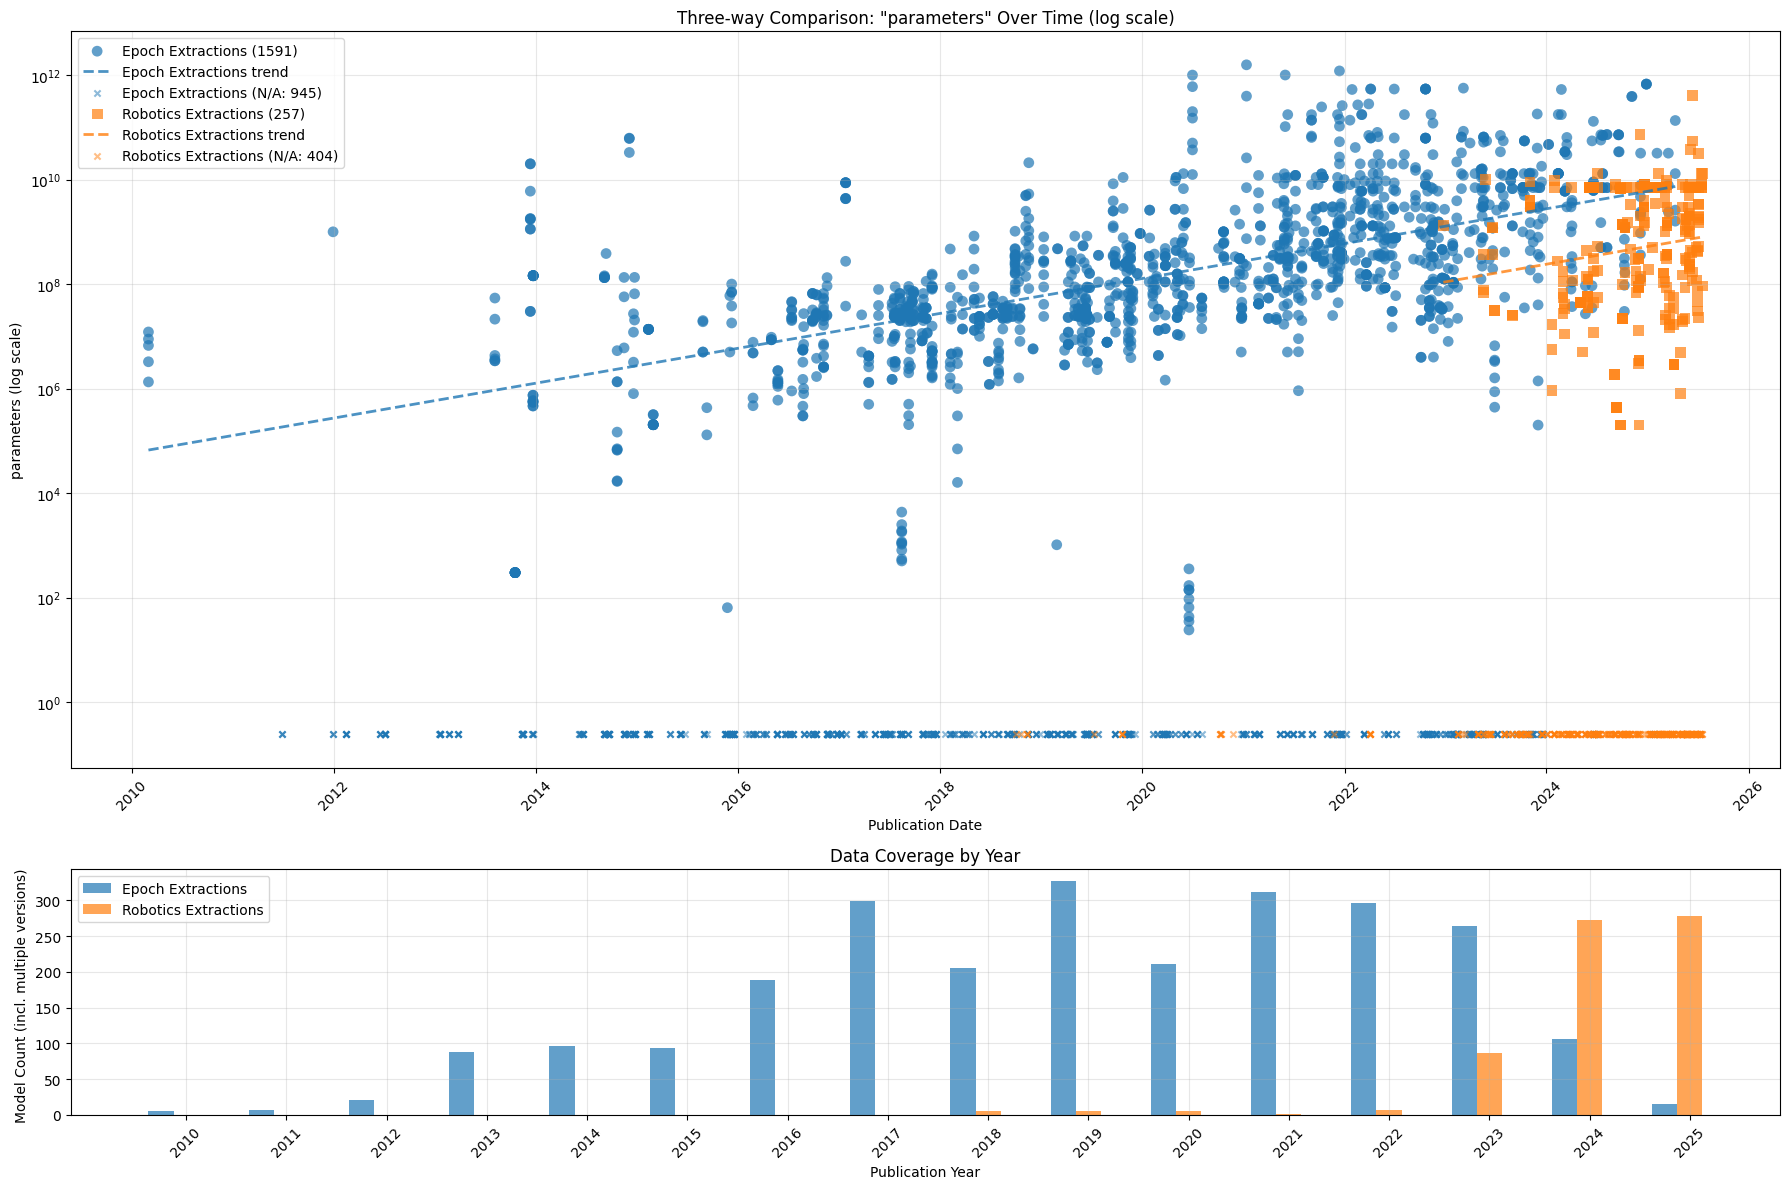


 Epoch Extractions Statistics:
  • Total data points: 2536
  • Date range: 2010-03-01 to 2025-04-10
  • Run ID range: 9976 to 10454
  • Average confidence: 88.5
  • Numeric values: 1591/2536 (62.7%)
  • Value range: 24 - 1571000000000
  • Median value: 133000000
  • N/A values: 945/2536 (37.3%)

 Robotics Extractions Statistics:
  • Total data points: 661
  • Date range: 2018-10-03 to 2025-07-17
  • Run ID range: 7866 to 8087
  • Average confidence: 75.5
  • Numeric values: 257/661 (38.9%)
  • Value range: 200000 - 405000000000
  • Median value: 1000000000
  • N/A values: 404/661 (61.1%)

 Dataset Overlaps:
  • Epoch Extractions ∩ Robotics Extractions: 0 papers (0.0% of combined unique papers)


In [23]:
# Example 1: Compare early vs recent extractions with CSV data
# Define two different time periods from database extractions
epoch_extraction_range_start = 9976  # Earlier run IDs
epoch_extraction_range_end = 10454
robotics_range_start = 7866  # More recent run IDs
robotics_range_end = 8087

# First, make sure we have CSV data available
if 'epoch_data' not in locals():
    print("️ No CSV data found. Please run the CSV processing cell first.")
    print(" Looking for 'Epoch Database - Notable Models.csv' file...")
else:
    # Compare parameter trends across all three data sources
    range1_df, range2_df, csv_df = compare_two_ranges_with_csv(
        field_name='parameters',
        csv_df=epoch_data,  # Use the processed CSV data
        range1_start=epoch_extraction_range_start,
        range1_end=epoch_extraction_range_end,
        range1_label='Epoch Extractions',
        range2_start=robotics_range_start,
        range2_end=robotics_range_end,
        range2_label='Robotics Extractions',
        csv_label='Epoch Originals',
        figsize=(18, 12),
        log_scale=True
    )

 Three-way comparison: architecture
 Mid-Period Extractions: 75 - 100
 Latest Extractions: 125 - 150
 Epoch Notable Models: 0 papers
 Mid-Period Extractions: Found 37 data points
   Date range: 2019-11-25 18:56:12+00:00 to 2025-04-10 15:41:51+00:00
   Run ID range: 75 to 100
 Latest Extractions: Found 51 data points
   Date range: 2014-12-22 13:54:29+00:00 to 2024-10-10 12:33:46+00:00
   Run ID range: 125 to 150

 Combined Statistics:
Total data points: 88
Numeric values: 0 (0.0%)
N/A values: 0 (0.0%)


/var/folders/ry/w884b67x1r316pnknj1yxy100000gn/T/ipykernel_63365/751297114.py:313: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()


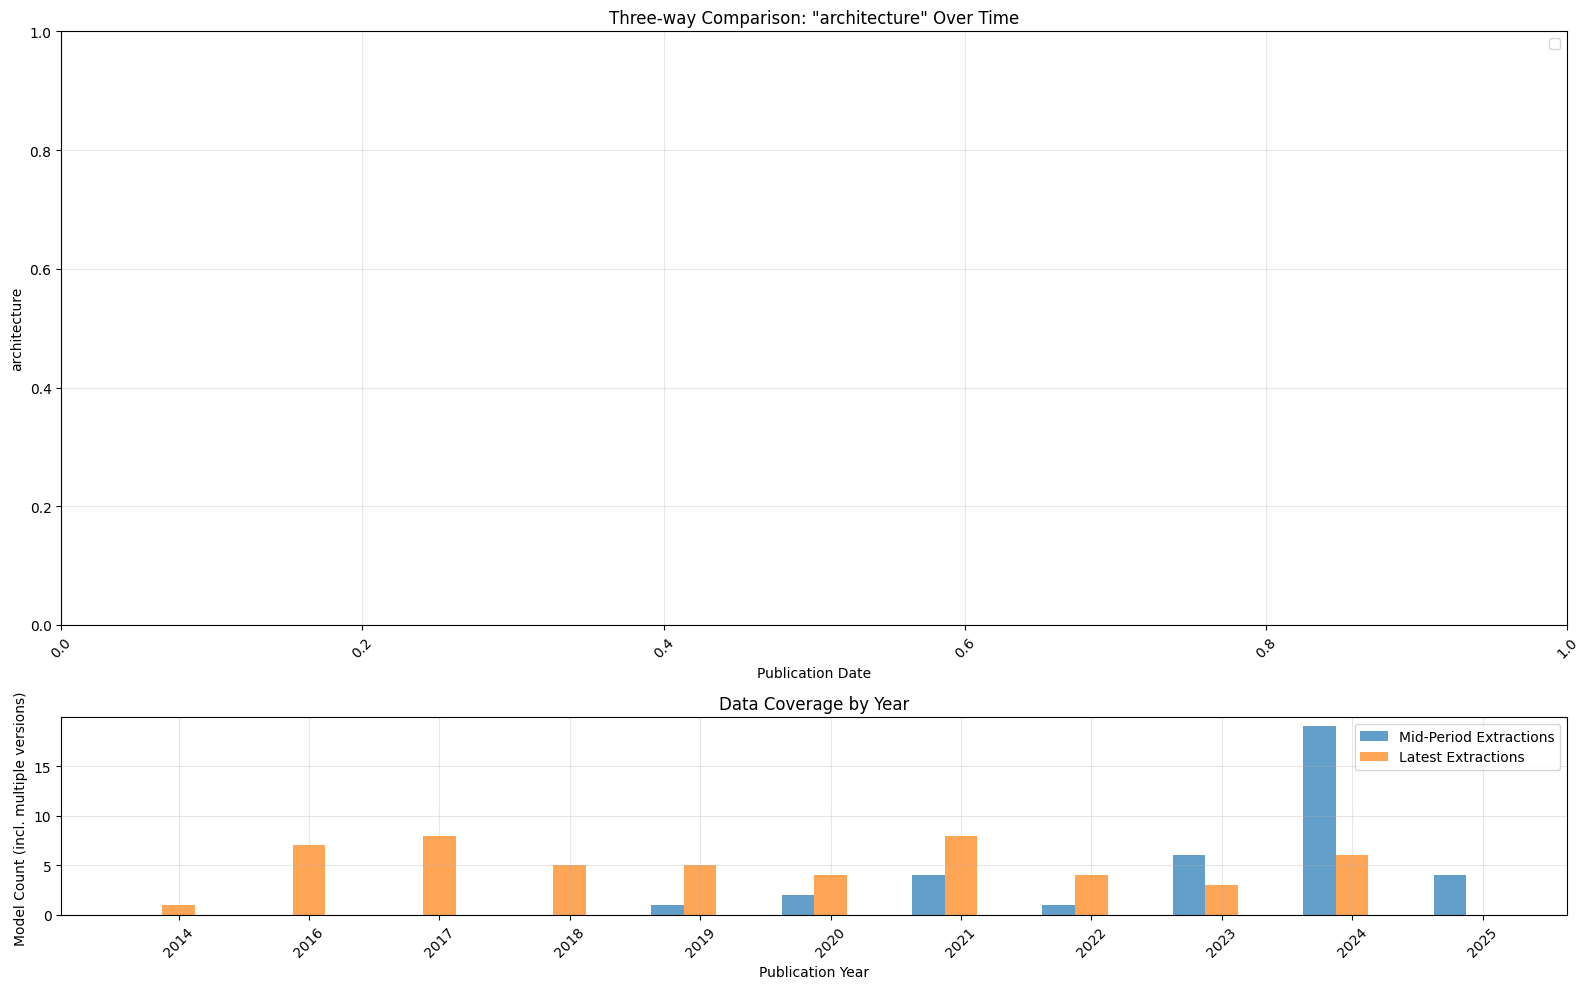


 Mid-Period Extractions Statistics:
  • Total data points: 37
  • Date range: 2019-11-25 to 2025-04-10
  • Run ID range: 75 to 100
  • Average confidence: 93.0

 Latest Extractions Statistics:
  • Total data points: 51
  • Date range: 2014-12-22 to 2024-10-10
  • Run ID range: 125 to 150
  • Average confidence: 94.1

 Dataset Overlaps:
  • Mid-Period Extractions ∩ Latest Extractions: 1 papers (2.0% of combined unique papers)


In [24]:
# Example 2: Compare specific extraction ranges for architecture analysis
# Focus on architecture field trends (if you have architecture data)
if 'epoch_data' not in locals():
    print("️ No CSV data found. Please run the CSV processing cell first.")
else:
    range1_df, range2_df, csv_df = compare_two_ranges_with_csv(
        field_name='architecture',  # Different field
        csv_df=epoch_data,
        range1_start=75,
        range1_end=100,
        range1_label='Mid-Period Extractions',
        range2_start=125,
        range2_end=150,
        range2_label='Latest Extractions',
        csv_label='Epoch Notable Models',
        figsize=(16, 10),
        log_scale=False  # Architecture is typically categorical, so no log scale
    )

## Additional Analysis Utilities

The following cells provide additional analysis capabilities for deeper insights into the data trends and patterns.

In [25]:
def get_statistical_summary(start_run_id, end_run_id, field='parameters'):
    """
    Get statistical summary for a specific database range and compare with CSV data.
    
    Args:
        start_run_id (int): Starting run ID for database query
        end_run_id (int): Ending run ID for database query  
        field (str): Field to analyze ('parameters', 'architecture', etc.)
    
    Returns:
        dict: Statistical summary comparing database and CSV data
    """
    # Get database data
    db_data = get_field_data_by_run_range(start_run_id, end_run_id, field)
    
    # Get CSV data (reuse if already processed)
    if 'epoch_data' not in globals():
        epoch_data = process_csv_with_arxiv_lookup()
    else:
        epoch_data = globals()['epoch_data']
    
    # Filter valid numeric values
    db_numeric = pd.to_numeric(db_data[field], errors='coerce').dropna()
    csv_numeric = pd.to_numeric(epoch_data[field], errors='coerce').dropna()
    
    # Calculate statistics
    stats = {
        'database': {
            'count': len(db_numeric),
            'mean': db_numeric.mean(),
            'median': db_numeric.median(),
            'std': db_numeric.std(),
            'min': db_numeric.min(),
            'max': db_numeric.max(),
            'q25': db_numeric.quantile(0.25),
            'q75': db_numeric.quantile(0.75)
        },
        'csv': {
            'count': len(csv_numeric),
            'mean': csv_numeric.mean(),
            'median': csv_numeric.median(), 
            'std': csv_numeric.std(),
            'min': csv_numeric.min(),
            'max': csv_numeric.max(),
            'q25': csv_numeric.quantile(0.25),
            'q75': csv_numeric.quantile(0.75)
        }
    }
    
    # Print formatted summary
    print(f"Statistical Summary for '{field}' field:")
    print(f"Database Range (Run {start_run_id}-{end_run_id}):")
    for key, value in stats['database'].items():
        print(f"  {key}: {value:.2f}" if isinstance(value, float) else f"  {key}: {value}")
    
    print(f"\nCSV Data (Epoch Database):")
    for key, value in stats['csv'].items():
        print(f"  {key}: {value:.2f}" if isinstance(value, float) else f"  {key}: {value}")
    
    # Calculate differences
    print(f"\nComparisons:")
    print(f"  Mean difference: {stats['database']['mean'] - stats['csv']['mean']:.2f}")
    print(f"  Median difference: {stats['database']['median'] - stats['csv']['median']:.2f}")
    print(f"  Count ratio (DB/CSV): {stats['database']['count'] / stats['csv']['count']:.2f}")
    
    return stats

In [26]:
def analyze_temporal_trends(field='parameters', window_years=2):
    """
    Analyze temporal trends in a field across both database and CSV data.
    
    Args:
        field (str): Field to analyze
        window_years (int): Rolling window size in years for trend analysis
    
    Returns:
        tuple: (db_trends, csv_trends) DataFrames with temporal statistics
    """
    # Get all database data (you may want to specify a range)
    all_db_data = get_field_data_by_run_range(1, 200, field)  # Adjust range as needed
    
    # Get CSV data
    if 'epoch_data' not in globals():
        epoch_data = process_csv_with_arxiv_lookup()
    else:
        epoch_data = globals()['epoch_data']
    
    # Convert to numeric and group by year
    all_db_data[field] = pd.to_numeric(all_db_data[field], errors='coerce')
    epoch_data[field] = pd.to_numeric(epoch_data[field], errors='coerce')
    
    all_db_data['year'] = all_db_data['publication_date'].dt.year
    epoch_data['year'] = epoch_data['publication_date'].dt.year
    
    # Calculate yearly statistics
    db_yearly = all_db_data.groupby('year')[field].agg([
        'count', 'mean', 'median', 'std'
    ]).reset_index()
    
    csv_yearly = epoch_data.groupby('year')[field].agg([
        'count', 'mean', 'median', 'std'
    ]).reset_index()
    
    # Calculate rolling trends
    db_yearly['rolling_mean'] = db_yearly['mean'].rolling(window=window_years, center=True).mean()
    csv_yearly['rolling_mean'] = csv_yearly['mean'].rolling(window=window_years, center=True).mean()
    
    # Plot trends
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Mean trends
    axes[0,0].plot(db_yearly['year'], db_yearly['mean'], 'o-', label='Database (Yearly)', alpha=0.7)
    axes[0,0].plot(db_yearly['year'], db_yearly['rolling_mean'], '-', label=f'Database ({window_years}-yr avg)', linewidth=2)
    axes[0,0].plot(csv_yearly['year'], csv_yearly['mean'], 's-', label='CSV (Yearly)', alpha=0.7)
    axes[0,0].plot(csv_yearly['year'], csv_yearly['rolling_mean'], '-', label=f'CSV ({window_years}-yr avg)', linewidth=2)
    axes[0,0].set_title(f'{field.title()} - Mean Trends Over Time')
    axes[0,0].set_xlabel('Year')
    axes[0,0].set_ylabel(f'Mean {field}')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)
    
    # Count trends
    axes[0,1].bar(db_yearly['year'] - 0.2, db_yearly['count'], width=0.4, label='Database', alpha=0.7)
    axes[0,1].bar(csv_yearly['year'] + 0.2, csv_yearly['count'], width=0.4, label='CSV', alpha=0.7)
    axes[0,1].set_title('Data Availability Over Time')
    axes[0,1].set_xlabel('Year')
    axes[0,1].set_ylabel('Number of Records')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)
    
    # Standard deviation trends
    axes[1,0].plot(db_yearly['year'], db_yearly['std'], 'o-', label='Database', alpha=0.7)
    axes[1,0].plot(csv_yearly['year'], csv_yearly['std'], 's-', label='CSV', alpha=0.7)
    axes[1,0].set_title(f'{field.title()} - Variability Over Time')
    axes[1,0].set_xlabel('Year')
    axes[1,0].set_ylabel(f'Standard Deviation')
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3)
    
    # Median trends
    axes[1,1].plot(db_yearly['year'], db_yearly['median'], 'o-', label='Database', alpha=0.7)
    axes[1,1].plot(csv_yearly['year'], csv_yearly['median'], 's-', label='CSV', alpha=0.7)
    axes[1,1].set_title(f'{field.title()} - Median Trends Over Time')
    axes[1,1].set_xlabel('Year')
    axes[1,1].set_ylabel(f'Median {field}')
    axes[1,1].legend()
    axes[1,1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return db_yearly, csv_yearly

In [27]:
# Example: Get statistical summary for a specific range
stats = get_statistical_summary(start_run_id=50, end_run_id=100, field='parameters')

# The stats dictionary can be used for further analysis or reporting

NameError: name 'get_field_data_by_run_range' is not defined

In [28]:
# Example: Analyze temporal trends in parameters
db_trends, csv_trends = analyze_temporal_trends(field='parameters', window_years=3)

print("Database trends by year:")
print(db_trends.head())
print("\nCSV trends by year:")
print(csv_trends.head())

NameError: name 'get_field_data_by_run_range' is not defined

## Summary and Next Steps

This notebook now provides comprehensive analysis capabilities for comparing trends in extracted fields across:

1. **Database Extractions**: Multiple run ID ranges from your OCR analysis pipeline
2. **CSV Data**: The Epoch Database of Notable Models with arXiv integration
3. **Combined Analysis**: Three-way comparisons and temporal trend analysis

### Key Functions Added:

- `process_csv_with_arxiv_lookup()`: Process CSV data and match with database publication dates
- `compare_field_trends()`: Compare two database run ID ranges
- `compare_two_ranges_with_csv()`: Three-way comparison (2 DB ranges + CSV)
- `get_statistical_summary()`: Statistical comparison between database and CSV data
- `analyze_temporal_trends()`: Comprehensive temporal analysis with rolling averages

### Typical Workflow:

1. **Explore Data**: Use exploration functions to understand data structure
2. **Process CSV**: Run `process_csv_with_arxiv_lookup()` to prepare CSV data
3. **Compare Trends**: Use comparison functions to visualize trends
4. **Statistical Analysis**: Get detailed statistics and temporal patterns
5. **Customize**: Adjust parameters, fields, and visualization options as needed

### Customization Options:

- **Fields**: 'parameters', 'architecture', 'dataset', or any extracted field
- **Time Ranges**: Adjust run ID ranges and publication date filters
- **Visualization**: Modify bins, colors, labels, and plot types
- **Statistics**: Choose different aggregation methods and time windows

The analysis pipeline is now ready for comprehensive trend analysis across your research paper extraction results!

## Categorical Distribution Analysis Over Time

The following function analyzes how categorical fields (like architecture, domain, task) evolve over time using grouped bar charts with flexible time periods.

In [29]:
def analyze_categorical_distribution_over_time(
    field_name, 
    months_per_group=12,           # 1=monthly, 3=quarterly, 12=yearly
    run_id_start=None,             # Optional filtering
    run_id_end=None,
    min_count_threshold=1,         # Only show categories with at least N occurrences
    top_n_categories=None,         # Optional: limit to top N most frequent categories
    exclude_top_k=0,               # NEW: Exclude top k most frequent categories
    category_rank_range=None,      # NEW: Show only categories ranked [k, n] e.g., (5, 15)
    figsize=(15, 8)
):
    """
    Analyze categorical field distribution over time with flexible time grouping and ranking filters.
    
    Args:
        field_name (str): Name of the categorical field to analyze (e.g., 'architecture', 'domain', 'task')
        months_per_group (int): Time grouping - 1=monthly, 3=quarterly, 12=yearly, etc.
        run_id_start (int, optional): Starting extraction run ID (inclusive)
        run_id_end (int, optional): Ending extraction run ID (inclusive)
        min_count_threshold (int): Only show categories with at least this many occurrences
        top_n_categories (int, optional): Limit to top N most frequent categories overall
        exclude_top_k (int): Exclude top k most frequent categories (useful for discovering emerging categories)
        category_rank_range (tuple, optional): Show only categories ranked [k, n], e.g., (5, 15) shows ranks 5-15
        figsize (tuple): Figure size for the plot
    
    Returns:
        pandas.DataFrame: Pivot table with time periods as columns and categories as rows
    """
    
    import pandas as pd
    import matplotlib.pyplot as plt
    import numpy as np
    import json
    from datetime import datetime
    from db.db_utils import get_connection
    
    print(f" Analyzing '{field_name}' distribution over time...")
    print(f" Time grouping: {months_per_group} month(s) per group")
    
    # Build the query to get extraction data with publication dates
    conn = get_connection()
    cursor = conn.cursor()
    
    query = """
    SELECT 
        ef.value,
        ef.confidence,
        ef.run_id,
        p.published_date,
        p.arxiv_id,
        p.title
    FROM extracted_fields ef
    JOIN extraction_runs er ON ef.run_id = er.id
    JOIN papers p ON er.paper_id = p.id
    WHERE ef.field_name = %s
    AND p.published_date IS NOT NULL
    AND ef.value IS NOT NULL
    AND ef.value != 'n/a'
    AND ef.value != ''
    """
    
    params = [field_name]
    
    # Add run ID filters if specified
    if run_id_start is not None:
        query += " AND ef.run_id >= %s"
        params.append(run_id_start)
    
    if run_id_end is not None:
        query += " AND ef.run_id <= %s"
        params.append(run_id_end)
    
    query += " ORDER BY p.published_date"
    
    cursor.execute(query, params)
    results = cursor.fetchall()
    conn.close()
    
    if not results:
        print(f" No data found for field '{field_name}' in the specified range.")
        return None
    
    # Convert to DataFrame
    df = pd.DataFrame(results, columns=[
        'value', 'confidence', 'run_id', 'published_date', 'arxiv_id', 'title'
    ])
    
    print(f" Found {len(df)} data points")
    print(f" Date range: {df['published_date'].min()} to {df['published_date'].max()}")
    
    # Convert publication dates to datetime
    df['published_date'] = pd.to_datetime(df['published_date'], utc=True)
    
    # Parse and normalize list-based values
    expanded_data = []
    
    for _, row in df.iterrows():
        value = row['value']
        
        # Use the new normalization function
        normalized_values = parse_and_normalize_list_values(value)
        
        # Add each normalized value as a separate row
        for normalized_val in normalized_values:
            expanded_data.append({
                'category': normalized_val,
                'published_date': row['published_date'],
                'run_id': row['run_id'],
                'arxiv_id': row['arxiv_id'],
                'confidence': row['confidence']
            })
    
    if not expanded_data:
        print(f" No valid categorical data found after parsing.")
        return None
    
    # Convert to DataFrame
    expanded_df = pd.DataFrame(expanded_data)
    print(f" Expanded to {len(expanded_df)} individual category entries")
    
    # Create time period grouping
    def create_time_period(date, months_per_group):
        if months_per_group == 1:
            return date.strftime('%Y-%m')
        elif months_per_group == 3:
            quarter = (date.month - 1) // 3 + 1
            return f"{date.year}-Q{quarter}"
        elif months_per_group == 12:
            return str(date.year)
        else:
            # Custom grouping
            period = (date.month - 1) // months_per_group + 1
            return f"{date.year}-P{period}"
    
    expanded_df['time_period'] = expanded_df['published_date'].apply(
        lambda x: create_time_period(x, months_per_group)
    )
    
    # Count occurrences by time period and category
    count_df = expanded_df.groupby(['time_period', 'category']).size().reset_index(name='count')
    
    # Filter by minimum count threshold
    if min_count_threshold > 1:
        category_totals = count_df.groupby('category')['count'].sum()
        valid_categories = category_totals[category_totals >= min_count_threshold].index
        count_df = count_df[count_df['category'].isin(valid_categories)]
        print(f" Filtered to {len(valid_categories)} categories with at least {min_count_threshold} occurrences")
    
    # Apply ranking-based filters
    category_totals = count_df.groupby('category')['count'].sum().sort_values(ascending=False)
    
    # Handle exclude_top_k parameter
    if exclude_top_k > 0:
        remaining_categories = category_totals.iloc[exclude_top_k:]  # Skip top k categories
        count_df = count_df[count_df['category'].isin(remaining_categories.index)]
        print(f" Excluded top {exclude_top_k} most frequent categories")
        print(f"   Excluded: {list(category_totals.head(exclude_top_k).index)}")
        category_totals = remaining_categories  # Update for further filtering
    
    # Handle category_rank_range parameter
    if category_rank_range is not None:
        start_rank, end_rank = category_rank_range
        # Convert to 0-based indexing
        start_idx = max(0, start_rank - 1)
        end_idx = min(len(category_totals), end_rank)
        
        if start_idx >= len(category_totals):
            print(f" Start rank {start_rank} exceeds available categories ({len(category_totals)})")
            return None
        
        selected_categories = category_totals.iloc[start_idx:end_idx]
        count_df = count_df[count_df['category'].isin(selected_categories.index)]
        print(f" Selected categories ranked {start_rank}-{end_rank}")
        print(f"   Selected: {list(selected_categories.index)}")
        category_totals = selected_categories
    
    # Handle top_n_categories parameter (applied after other filters)
    elif top_n_categories is not None:
        top_categories = category_totals.head(top_n_categories)
        count_df = count_df[count_df['category'].isin(top_categories.index)]
        print(f" Limited to top {top_n_categories} most frequent categories (after other filters)")
        category_totals = top_categories
    
    # Create pivot table for plotting
    pivot_df = count_df.pivot(index='category', columns='time_period', values='count').fillna(0)
    
    # Sort columns chronologically
    try:
        if months_per_group == 12:
            sorted_columns = sorted(pivot_df.columns, key=lambda x: int(x))
        else:
            sorted_columns = sorted(pivot_df.columns)
        pivot_df = pivot_df[sorted_columns]
    except:
        pass  # Keep original order if sorting fails
    
    # Sort rows by total frequency (descending)
    row_totals = pivot_df.sum(axis=1).sort_values(ascending=False)
    pivot_df = pivot_df.loc[row_totals.index]
    
    print(f" Final data shape: {pivot_df.shape} (categories × time periods)")
    print(f"️  Categories: {list(pivot_df.index)}")
    print(f" Time periods: {list(pivot_df.columns)}")
    
    # Create the grouped bar chart
    fig, ax = plt.subplots(figsize=figsize)
    
    # Set up the bar positions
    x_pos = np.arange(len(pivot_df.columns))
    bar_width = 0.8 / len(pivot_df.index)  # Adjust width based on number of categories
    
    # Create color palette
    colors = plt.cm.Set1(np.linspace(0, 1, len(pivot_df.index)))
    
    # Plot each category as a separate bar group
    for i, (category, row) in enumerate(pivot_df.iterrows()):
        # Only plot bars for time periods where count > 0
        non_zero_mask = row > 0
        if non_zero_mask.sum() > 0:
            positions = x_pos[non_zero_mask] + i * bar_width
            values = row[non_zero_mask]
            ax.bar(positions, values, bar_width, 
                  label=category, color=colors[i], alpha=0.8)
    
    # Customize the plot
    ax.set_xlabel('Time Period')
    ax.set_ylabel('Count')
    ax.set_title(f'{field_name.title()} Distribution Over Time\n'
                f'(Grouped by {months_per_group} month{"s" if months_per_group > 1 else ""})')
    
    # Set x-axis labels
    ax.set_xticks(x_pos + bar_width * (len(pivot_df.index) - 1) / 2)
    ax.set_xticklabels(pivot_df.columns, rotation=45, ha='right')
    
    # Add legend
    if len(pivot_df.index) <= 15:  # Only show legend if not too many categories
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        print("️  Legend hidden due to too many categories")
    
    # Add grid
    ax.grid(True, alpha=0.3, axis='y')
    
    # Adjust layout
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\n Summary Statistics:")
    print(f"  • Total time periods: {len(pivot_df.columns)}")
    print(f"  • Total categories: {len(pivot_df.index)}")
    print(f"  • Total occurrences: {pivot_df.sum().sum():.0f}")
    print(f"  • Average per time period: {pivot_df.sum(axis=0).mean():.1f}")
    print(f"  • Most frequent category: {row_totals.index[0]} ({row_totals.iloc[0]:.0f} total)")
    
    # Show top categories per time period
    print(f"\n Top category per time period:")
    for col in pivot_df.columns:
        top_category = pivot_df[col].idxmax()
        top_count = pivot_df[col].max()
        if top_count > 0:
            print(f"  • {col}: {top_category} ({top_count:.0f})")
    
    return pivot_df

print(" Categorical distribution analysis function loaded!")

 Categorical distribution analysis function loaded!


In [30]:
def normalize_category_value(value):
    """
    Normalize category values by cleaning up inconsistent formatting.
    
    Handles cases like:
    - '{Language}' -> 'Language'
    - 'Vision}' -> 'Vision' 
    - '{Language' -> 'Language'
    - '{"Image generation"' -> 'Image generation'
    - 'Language' -> 'Language' (unchanged)
    
    Args:
        value (str): Raw category value to normalize
    
    Returns:
        str: Cleaned category value
    """
    if not value or pd.isna(value):
        return None
    
    # Convert to string and strip whitespace
    cleaned = str(value).strip()
    
    # Remove common JSON-like artifacts
    # Remove leading/trailing braces
    cleaned = cleaned.strip('{}')
    
    # Remove leading/trailing quotes (both single and double)
    cleaned = cleaned.strip('\'"')
    
    # Remove any remaining braces that might be in the middle
    cleaned = cleaned.replace('{', '').replace('}', '')
    
    # Remove quotes that might be in the middle  
    cleaned = cleaned.replace('"', '').replace("'", "")
    
    # Clean up whitespace
    cleaned = cleaned.strip()
    
    # Return None for empty results
    if not cleaned or cleaned.lower() in ['n/a', 'none', 'null', '']:
        return None
    
    return cleaned

def parse_and_normalize_list_values(value):
    """
    Parse and normalize list-based category values with robust error handling.
    
    Handles various formats:
    - JSON arrays: ["Vision", "Language"]
    - JSON sets: {"Vision", "Language", "Multimodal"}
    - Comma-separated: "Vision, Language"
    - Malformed: {Vision}, {Language
    
    Args:
        value: Raw value that might be a list, JSON string, or single value
    
    Returns:
        list: List of normalized category values
    """
    if not value or pd.isna(value):
        return []
    
    normalized_values = []
    value_str = str(value).strip()
    
    try:
        # Case 1: JSON array format ["item1", "item2"]
        if value_str.startswith('[') and value_str.endswith(']'):
            try:
                values_list = json.loads(value_str)
            except json.JSONDecodeError:
                # If JSON parsing fails, manually extract content
                bracket_content = value_str[1:-1]  # Remove [ and ]
                values_list = [v.strip() for v in bracket_content.split(',')]
        
        # Case 2: JSON set format {"item1", "item2", "item3"}
        elif value_str.startswith('{') and value_str.endswith('}') and ',' in value_str:
            # Extract content between braces and split by comma
            brace_content = value_str[1:-1]  # Remove { and }
            values_list = [v.strip() for v in brace_content.split(',')]
        
        # Case 3: Comma-separated values (no brackets/braces or mixed format)
        elif ',' in value_str:
            values_list = [v.strip() for v in value_str.split(',')]
        
        # Case 4: Python list object
        elif isinstance(value, list):
            values_list = value
        
        # Case 5: Single value (including single items in braces like {Vision})
        else:
            values_list = [value_str]
        
        # Normalize each value in the list
        for val in values_list:
            normalized = normalize_category_value(val)
            if normalized:  # Only add non-None values
                normalized_values.append(normalized)
                
    except Exception as e:
        # If all parsing fails, try to normalize as single value
        normalized = normalize_category_value(value_str)
        if normalized:
            normalized_values.append(normalized)
    
    return normalized_values

print(" Category normalization functions loaded!")

 Category normalization functions loaded!


In [31]:
# Test the normalization function with your problematic values
test_values = [
    '{Language}', 
    '{Vision}', 
    'Vision}', 
    '{Language', 
    '{"Image generation"', 
    'Language', 
    '{"Image generation"}', 
    'Multimodal}', 
    '{Vision', 
    '{Audio'
]

print(" Testing category normalization:")
print("=" * 50)

for test_val in test_values:
    normalized = normalize_category_value(test_val)
    print(f"'{test_val}' → '{normalized}'")

print("\n Testing list parsing and normalization:")
print("=" * 50)

# Test some list-like values
test_list_values = [
    '[{Language}, {Vision}]',
    '{"Image generation"}, Multimodal}',
    '{Language, Vision, Audio}',
    'Language, Vision',
    '{"Vision", "Language", "Multimodal"}',  # New JSON set format
    '{"Vision", "Language"}',                 # Simpler JSON set
    '{Vision, Language, Audio}',              # Unquoted set format
]

for test_val in test_list_values:
    normalized_list = parse_and_normalize_list_values(test_val)
    print(f"'{test_val}' → {normalized_list}")

print("\n Normalization functions ready to use!")

 Testing category normalization:
'{Language}' → 'Language'
'{Vision}' → 'Vision'
'Vision}' → 'Vision'
'{Language' → 'Language'
'{"Image generation"' → 'Image generation'
'Language' → 'Language'
'{"Image generation"}' → 'Image generation'
'Multimodal}' → 'Multimodal'
'{Vision' → 'Vision'
'{Audio' → 'Audio'

 Testing list parsing and normalization:
'[{Language}, {Vision}]' → ['[Language, Vision]']
'{"Image generation"}, Multimodal}' → ['Image generation', 'Multimodal']
'{Language, Vision, Audio}' → ['Language', 'Vision', 'Audio']
'Language, Vision' → ['Language', 'Vision']
'{"Vision", "Language", "Multimodal"}' → ['Vision', 'Language', 'Multimodal']
'{"Vision", "Language"}' → ['Vision', 'Language']
'{Vision, Language, Audio}' → ['Vision', 'Language', 'Audio']

 Normalization functions ready to use!


 Example 1: Architecture distribution by year
 Analyzing 'architecture' distribution over time...
 Time grouping: 12 month(s) per group
 Found 33474 data points
 Date range: 2010-03-01 15:32:11+01:00 to 2025-07-17 10:31:55+02:00
 Expanded to 33474 individual category entries
 Filtered to 63 categories with at least 2 occurrences
 Limited to top 10 most frequent categories (after other filters)
 Final data shape: (10, 16) (categories × time periods)
️  Categories: ['Transformer (Decoder-only)', 'Convolutional Neural Network (CNN)', 'Other / Custom Architecture', 'Hybrid CNN-Transformer', 'Transformer (Encoder-Decoder)', 'Recurrent Neural Network (RNN)', 'Transformer (Encoder-only)', 'Multimodal Transformer', 'Long Short-Term Memory (LSTM)', 'Vision Transformer (ViT)']
 Time periods: ['2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']


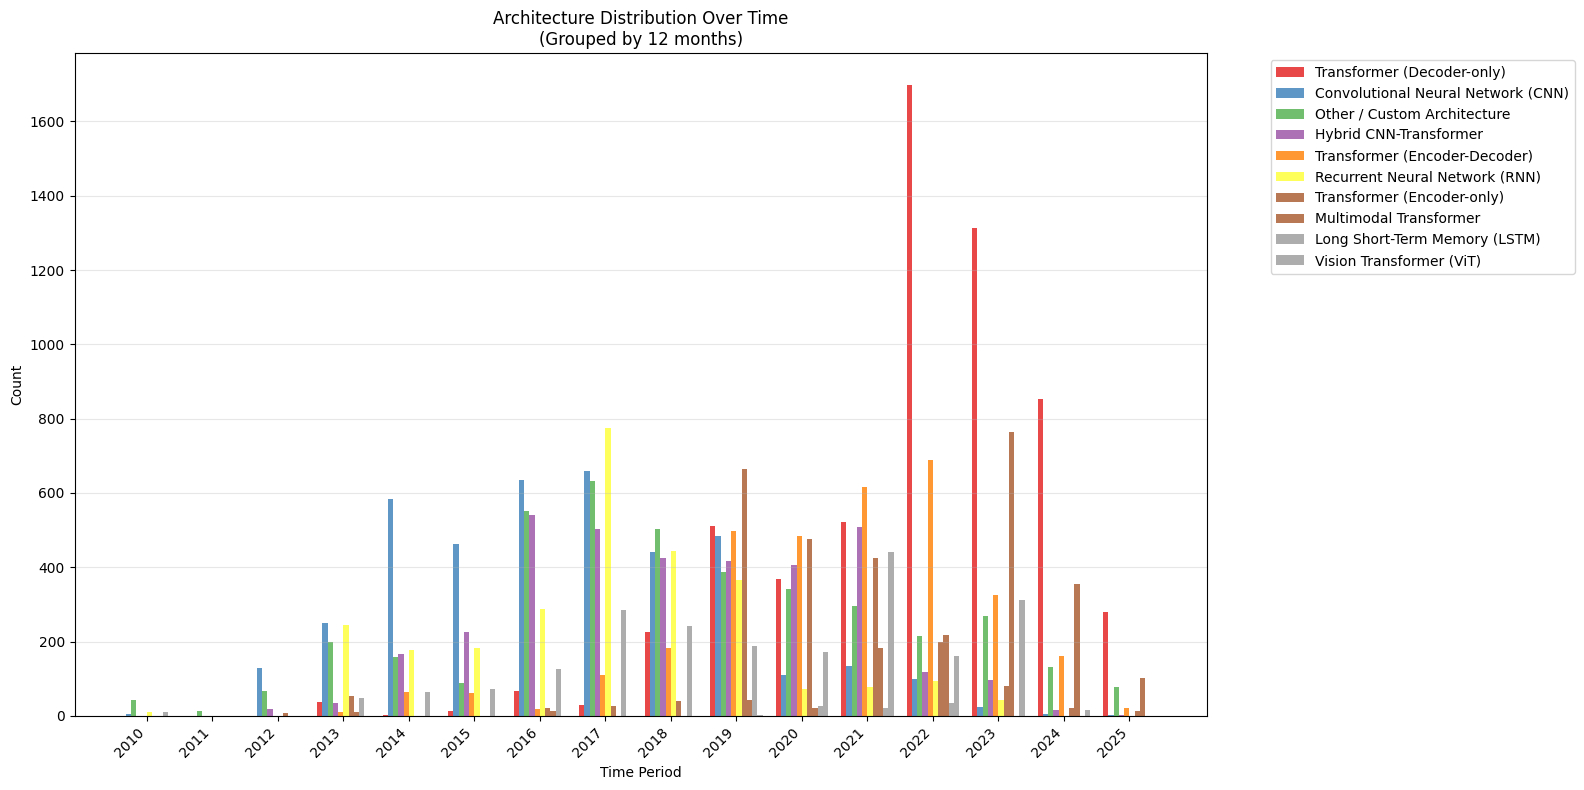


 Summary Statistics:
  • Total time periods: 16
  • Total categories: 10
  • Total occurrences: 29378
  • Average per time period: 1836.1
  • Most frequent category: Transformer (Decoder-only) (5920 total)

 Top category per time period:
  • 2010: Other / Custom Architecture (44)
  • 2011: Other / Custom Architecture (13)
  • 2012: Convolutional Neural Network (CNN) (128)
  • 2013: Convolutional Neural Network (CNN) (249)
  • 2014: Convolutional Neural Network (CNN) (585)
  • 2015: Convolutional Neural Network (CNN) (463)
  • 2016: Convolutional Neural Network (CNN) (636)
  • 2017: Recurrent Neural Network (RNN) (774)
  • 2018: Other / Custom Architecture (502)
  • 2019: Transformer (Encoder-only) (664)
  • 2020: Transformer (Encoder-Decoder) (483)
  • 2021: Transformer (Encoder-Decoder) (616)
  • 2022: Transformer (Decoder-only) (1699)
  • 2023: Transformer (Decoder-only) (1312)
  • 2024: Transformer (Decoder-only) (854)
  • 2025: Transformer (Decoder-only) (281)


In [32]:
# Example 1: Analyze architecture distribution by year
print(" Example 1: Architecture distribution by year")
architecture_yearly = analyze_categorical_distribution_over_time(
    field_name='architecture',
    months_per_group=12,  # Yearly grouping
    min_count_threshold=2,  # Only show architectures with at least 2 occurrences
    top_n_categories=10,   # Show top 10 most frequent architectures
    figsize=(16, 8)
)

 Example 2: Domain distribution by quarter
 Analyzing 'architecture' distribution over time...
 Time grouping: 12 month(s) per group
 Found 875 data points
 Date range: 2010-03-01 15:32:11+01:00 to 2025-04-10 17:41:51+02:00
 Expanded to 875 individual category entries
 Limited to top 15 most frequent categories (after other filters)
 Final data shape: (15, 16) (categories × time periods)
️  Categories: ['Transformer (Decoder-only)', 'Convolutional Neural Network (CNN)', 'ResNet Architecture', 'Transformer (Encoder-Decoder)', 'Transformer (Encoder-only)', 'Long Short-Term Memory (LSTM)', 'Other - High-Level Architecture Name', 'Recurrent Neural Network (RNN)', 'Vision Transformer (ViT)', 'Multimodal Transformer', 'Diffusion Model', 'Hybrid CNN-Transformer', 'Mixture of Experts (MoE)', 'Attention-based Architecture', 'Generative Adversarial Network (GAN)']
 Time periods: ['2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024

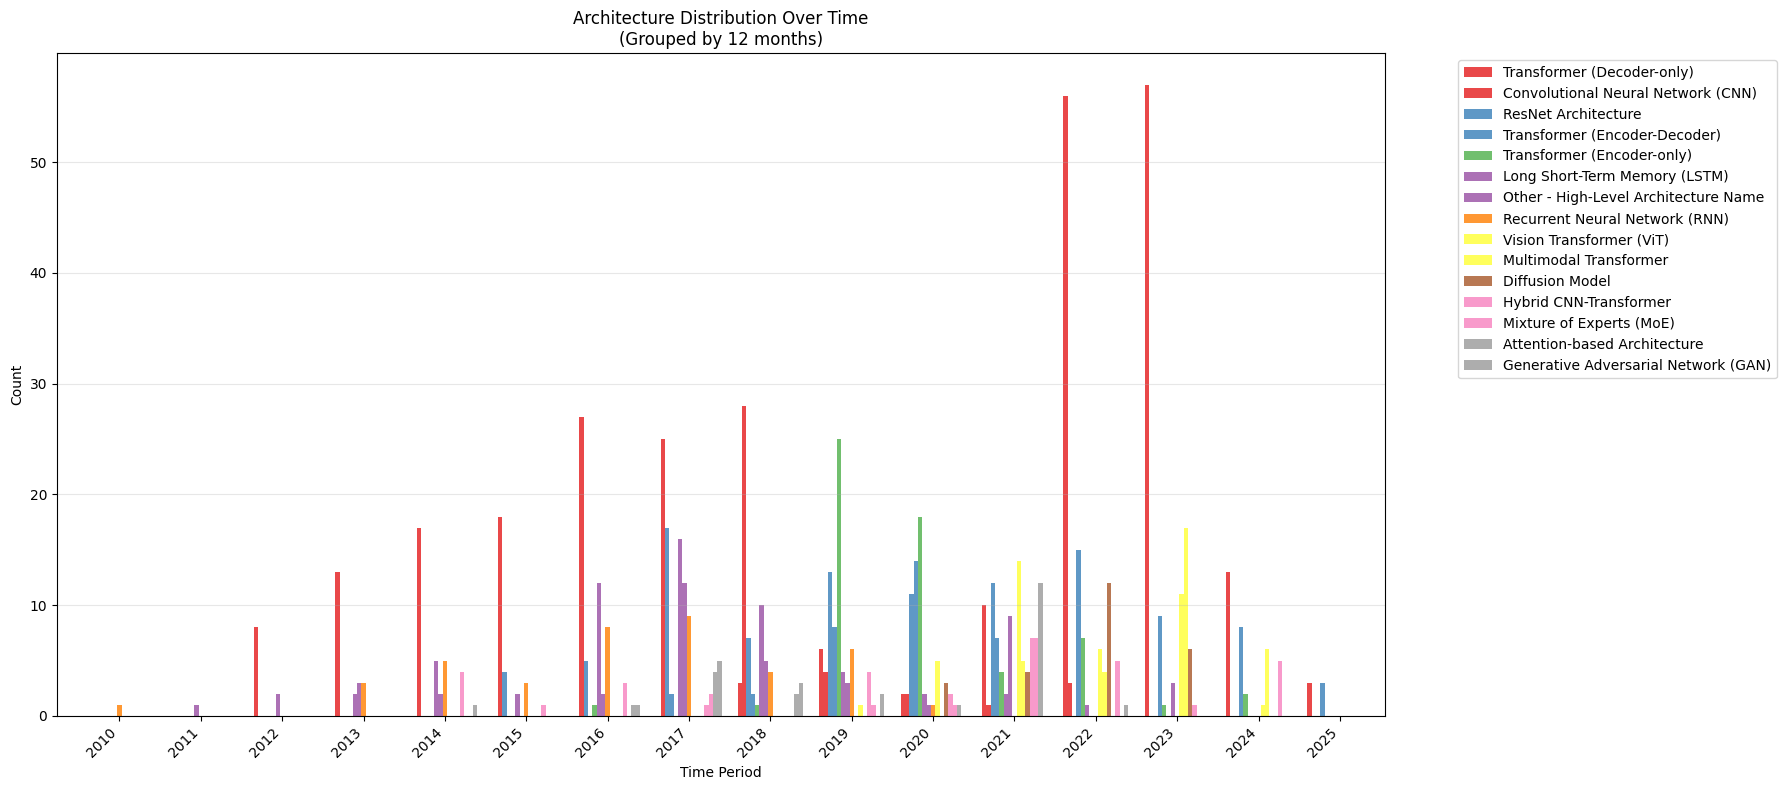


 Summary Statistics:
  • Total time periods: 16
  • Total categories: 15
  • Total occurrences: 803
  • Average per time period: 50.2
  • Most frequent category: Transformer (Decoder-only) (150 total)

 Top category per time period:
  • 2010: Recurrent Neural Network (RNN) (1)
  • 2011: Other - High-Level Architecture Name (1)
  • 2012: Convolutional Neural Network (CNN) (8)
  • 2013: Convolutional Neural Network (CNN) (13)
  • 2014: Convolutional Neural Network (CNN) (17)
  • 2015: Convolutional Neural Network (CNN) (18)
  • 2016: Convolutional Neural Network (CNN) (27)
  • 2017: Convolutional Neural Network (CNN) (25)
  • 2018: Convolutional Neural Network (CNN) (28)
  • 2019: Transformer (Encoder-only) (25)
  • 2020: Transformer (Encoder-only) (18)
  • 2021: Vision Transformer (ViT) (14)
  • 2022: Transformer (Decoder-only) (56)
  • 2023: Transformer (Decoder-only) (57)
  • 2024: Transformer (Decoder-only) (13)
  • 2025: Transformer (Decoder-only) (3)


In [33]:
# Example 2: Analyze domain distribution by quarter
print(" Example 2: Domain distribution by quarter")
domain_quarterly = analyze_categorical_distribution_over_time(
    field_name='architecture',  # Use 'domain' if you have that field
    months_per_group=12,   # Quarterly grouping
    min_count_threshold=1,
    run_id_start=9046,  # Optional: filter by run ID range
    run_id_end=9513,
    top_n_categories=15,
    exclude_top_k=0,  # Exclude top 5 most frequent domains
    figsize=(18, 8)
)

In [34]:
# Utility function: Explore available fields for categorical analysis
def explore_categorical_fields(run_id_start=None, run_id_end=None):
    """
    Explore available categorical fields and their basic statistics.
    
    Args:
        run_id_start (int, optional): Starting extraction run ID
        run_id_end (int, optional): Ending extraction run ID
    
    Returns:
        dict: Field statistics
    """
    from db.db_utils import get_connection
    
    conn = get_connection()
    cursor = conn.cursor()
    
    query = """
    SELECT 
        ef.field_name,
        COUNT(*) as total_extractions,
        COUNT(DISTINCT ef.value) as unique_values,
        COUNT(CASE WHEN ef.value != 'n/a' AND ef.value != '' AND ef.value IS NOT NULL THEN 1 END) as valid_extractions,
        AVG(ef.confidence) as avg_confidence
    FROM extracted_fields ef
    JOIN extraction_runs er ON ef.run_id = er.id
    JOIN papers p ON er.paper_id = p.id
    WHERE p.published_date IS NOT NULL
    """
    
    params = []
    if run_id_start is not None:
        query += " AND ef.run_id >= %s"
        params.append(run_id_start)
    if run_id_end is not None:
        query += " AND ef.run_id <= %s"
        params.append(run_id_end)
    
    query += " GROUP BY ef.field_name ORDER BY valid_extractions DESC"
    
    cursor.execute(query, params)
    results = cursor.fetchall()
    conn.close()
    
    print(" Available fields for categorical analysis:")
    print("=" * 80)
    
    field_stats = {}
    for result in results:
        field_name, total, unique, valid, confidence = result
        completeness = (valid / total * 100) if total > 0 else 0
        
        print(f"️  {field_name}")
        print(f"   • Total extractions: {total}")
        print(f"   • Valid extractions: {valid} ({completeness:.1f}%)")
        print(f"   • Unique values: {unique}")
        print(f"   • Average confidence: {confidence:.1f}")
        print()
        
        field_stats[field_name] = {
            'total_extractions': total,
            'valid_extractions': valid,
            'unique_values': unique,
            'completeness_rate': completeness,
            'avg_confidence': confidence
        }
    
    return field_stats

# Example: Explore available fields
print(" Exploring available categorical fields...")
field_info = explore_categorical_fields()

 Exploring available categorical fields...
 Available fields for categorical analysis:
️  model_name
   • Total extractions: 34115
   • Valid extractions: 33925 (99.4%)
   • Unique values: 6450
   • Average confidence: 97.9

️  domain
   • Total extractions: 33910
   • Valid extractions: 33910 (100.0%)
   • Unique values: 453
   • Average confidence: 95.4

️  architecture
   • Total extractions: 33537
   • Valid extractions: 33474 (99.8%)
   • Unique values: 117
   • Average confidence: 91.2

️  task
   • Total extractions: 33411
   • Valid extractions: 33400 (100.0%)
   • Unique values: 4508
   • Average confidence: 94.8

️  input_modality
   • Total extractions: 32498
   • Valid extractions: 32448 (99.8%)
   • Unique values: 123
   • Average confidence: 95.5

️  output_modality
   • Total extractions: 32459
   • Valid extractions: 32397 (99.8%)
   • Unique values: 78
   • Average confidence: 92.2

️  training_dataset
   • Total extractions: 32608
   • Valid extractions: 30994 (95.1%)

## Advanced Category Ranking and Filtering Examples

The following examples demonstrate how to use the new ranking-based filtering options to discover emerging categories and analyze specific rank ranges.

In [35]:
# Utility function: Preview category rankings to help decide on rank ranges
def preview_category_rankings(field_name, run_id_start=None, run_id_end=None, top_n=20):
    """
    Preview the ranking of categories for a field to help decide on filtering parameters.
    
    Args:
        field_name (str): Field to analyze
        run_id_start/end (int, optional): Run ID filters
        top_n (int): Number of top categories to show
    
    Returns:
        pandas.Series: Category rankings with counts
    """
    from db.db_utils import get_connection
    import pandas as pd
    
    conn = get_connection()
    cursor = conn.cursor()
    
    query = """
    SELECT ef.value
    FROM extracted_fields ef
    JOIN extraction_runs er ON ef.run_id = er.id
    JOIN papers p ON er.paper_id = p.id
    WHERE ef.field_name = %s
    AND p.published_date IS NOT NULL
    AND ef.value IS NOT NULL
    AND ef.value != 'n/a'
    AND ef.value != ''
    """
    
    params = [field_name]
    if run_id_start is not None:
        query += " AND ef.run_id >= %s"
        params.append(run_id_start)
    if run_id_end is not None:
        query += " AND ef.run_id <= %s"
        params.append(run_id_end)
    
    cursor.execute(query, params)
    results = cursor.fetchall()
    conn.close()
    
    # Process and normalize values
    all_categories = []
    for (value,) in results:
        normalized_values = parse_and_normalize_list_values(value)
        all_categories.extend(normalized_values)
    
    # Count and rank
    category_counts = pd.Series(all_categories).value_counts()
    
    print(f" Category Rankings for '{field_name}':")
    print("=" * 60)
    print(f"{'Rank':<6} {'Category':<30} {'Count':<8} {'%':<6}")
    print("-" * 60)
    
    total_count = category_counts.sum()
    for i, (category, count) in enumerate(category_counts.head(top_n).items(), 1):
        percentage = (count / total_count) * 100
        print(f"{i:<6} {category:<30} {count:<8} {percentage:.1f}%")
    
    if len(category_counts) > top_n:
        print(f"... and {len(category_counts) - top_n} more categories")
    
    print(f"\n Total categories: {len(category_counts)}")
    print(f" Total entries: {total_count}")
    
    return category_counts

# Example: Preview architecture rankings
print(" Preview architecture rankings to plan your analysis:")
arch_rankings = preview_category_rankings('architecture', top_n=15)

 Preview architecture rankings to plan your analysis:
 Category Rankings for 'architecture':
Rank   Category                       Count    %     
------------------------------------------------------------
1      Transformer (Decoder-only)     5920     17.7%
2      Convolutional Neural Network (CNN) 4026     12.0%
3      Other / Custom Architecture    3976     11.9%
4      Hybrid CNN-Transformer         3478     10.4%
5      Transformer (Encoder-Decoder)  3238     9.7%
6      Recurrent Neural Network (RNN) 2781     8.3%
7      Transformer (Encoder-only)     2028     6.1%
8      Multimodal Transformer         1710     5.1%
9      Long Short-Term Memory (LSTM)  1116     3.3%
10     Vision Transformer (ViT)       1105     3.3%
11     Mixture of Experts (MoE)       811      2.4%
12     Diffusion Model                768      2.3%
13     ResNet Architecture            628      1.9%
14     Latent Diffusion Model         270      0.8%
15     Other - High-Level Architecture Name 254      0.8